In [2]:
import duckdb
from pathlib import Path

In [3]:
working_directory = Path.cwd().parent.parent
DATABASE_PATH = working_directory / "data" / "database" / "f1_fantasy.duckdb"

### Meetings Table

In [4]:

def read_raw_meetings_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_meetings_table").df()

    return result

In [5]:
raw_query = read_raw_meetings_table()
raw_query

,meeting_key,meeting_name,meeting_official_name,location,country_key,country_code,country_name,country_flag,circuit_key,circuit_short_name,circuit_type,circuit_info_url,circuit_image,gmt_offset,date_start,date_end,year
0,1140,Pre-Season Testing,FORMULA 1 ARAMCO PRE-SEASON TESTING 2023,Sakhir,36,BRN,Bahrain,https://media.formula1.com/content/dam/fom-web...,63,Sakhir,Permanent,https://api.multiviewer.app/api/v1/circuits/63...,https://media.formula1.com/content/dam/fom-web...,03:00:00,2023-02-23T07:00:00+00:00,2023-02-25T16:30:00+00:00,2023
1,1141,Bahrain Grand Prix,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2023,Sakhir,36,BRN,Bahrain,https://media.formula1.com/content/dam/fom-web...,63,Sakhir,Permanent,https://api.multiviewer.app/api/v1/circuits/63...,https://media.formula1.com/content/dam/fom-web...,03:00:00,2023-03-03T11:30:00+00:00,2023-03-05T17:00:00+00:00,2023
2,1142,Saudi Arabian Grand Prix,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2023,Jeddah,153,KSA,Saudi Arabia,https://media.formula1.com/content/dam/fom-web...,149,Jeddah,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/14...,https://media.formula1.com/content/dam/fom-web...,03:00:00,2023-03-17T13:30:00+00:00,2023-03-19T19:00:00+00:00,2023
3,1143,Australian Grand Prix,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2023,Melbourne,5,AUS,Australia,https://media.formula1.com/content/dam/fom-web...,10,Melbourne,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/10...,https://media.formula1.com/content/dam/fom-web...,10:00:00,2023-03-31T02:30:00+00:00,2023-04-02T07:00:00+00:00,2023
4,1207,Azerbaijan Grand Prix,FORMULA 1 AZERBAIJAN GRAND PRIX 2023,Baku,30,AZE,Azerbaijan,https://media.formula1.com/content/dam/fom-web...,144,Baku,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/14...,https://media.formula1.com/content/dam/fom-web...,04:00:00,2023-04-28T09:30:00+00:00,2023-04-30T13:00:00+00:00,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,1298,Mexico City Grand Prix,FORMULA 1 GRAN PREMIO DE LA CIUDAD DE MÉXICO 2026,Mexico City,8,MEX,Mexico,https://media.formula1.com/content/dam/fom-web...,65,Mexico City,Permanent,https://api.multiviewer.app/api/v1/circuits/65...,https://media.formula1.com/content/dam/fom-web...,-06:00:00,2026-10-30T18:30:00+00:00,2026-11-01T22:00:00+00:00,2026
122,1299,São Paulo Grand Prix,FORMULA 1 MSC CRUISES GRANDE PRÊMIO DE SÃO PAU...,São Paulo,10,BRA,Brazil,https://media.formula1.com/content/dam/fom-web...,14,Interlagos,Permanent,https://api.multiviewer.app/api/v1/circuits/14...,https://media.formula1.com/content/dam/fom-web...,-03:00:00,2026-11-06T15:30:00+00:00,2026-11-08T19:00:00+00:00,2026
123,1300,Las Vegas Grand Prix,FORMULA 1 HEINEKEN LAS VEGAS GRAND PRIX 2026,Las Vegas,19,USA,United States,https://media.formula1.com/content/dam/fom-web...,152,Las Vegas,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/15...,https://media.formula1.com/content/dam/fom-web...,-08:00:00,2026-11-20T00:30:00+00:00,2026-11-22T06:00:00+00:00,2026
124,1301,Qatar Grand Prix,FORMULA 1 QATAR AIRWAYS QATAR GRAND PRIX 2026,Lusail,149,QAT,Qatar,https://media.formula1.com/content/dam/fom-web...,150,Lusail,Permanent,https://api.multiviewer.app/api/v1/circuits/15...,https://media.formula1.com/content/dam/fom-web...,03:00:00,2026-11-27T13:30:00+00:00,2026-11-29T18:00:00+00:00,2026


In [6]:
raw_query.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   meeting_key            126 non-null    int64 
 1   meeting_name           126 non-null    object
 2   meeting_official_name  126 non-null    object
 3   location               126 non-null    object
 4   country_key            126 non-null    int64 
 5   country_code           126 non-null    object
 6   country_name           126 non-null    object
 7   country_flag           126 non-null    object
 8   circuit_key            126 non-null    int64 
 9   circuit_short_name     126 non-null    object
 10  circuit_type           126 non-null    object
 11  circuit_info_url       126 non-null    object
 12  circuit_image          126 non-null    object
 13  gmt_offset             126 non-null    object
 14  date_start             126 non-null    object
 15  date_end               

In [7]:
def read_staged_meetings_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM staged_race_meetings_table").df()

    return result

In [8]:
staged_query = read_staged_meetings_table()
staged_query

,meeting_key,meeting_name,country_name,circuit_short_name,circuit_type,date_start,date_end,year
0,1141,Bahrain Grand Prix,Bahrain,Sakhir,Permanent,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,2023
1,1142,Saudi Arabian Grand Prix,Saudi Arabia,Jeddah,Temporary - Street,2023-03-17 09:30:00-04:00,2023-03-17 09:30:00-04:00,2023
2,1143,Australian Grand Prix,Australia,Melbourne,Temporary - Street,2023-03-30 22:30:00-04:00,2023-03-30 22:30:00-04:00,2023
3,1207,Azerbaijan Grand Prix,Azerbaijan,Baku,Temporary - Street,2023-04-28 05:30:00-04:00,2023-04-28 05:30:00-04:00,2023
4,1208,Miami Grand Prix,United States,Miami,Temporary - Street,2023-05-05 14:00:00-04:00,2023-05-05 14:00:00-04:00,2023
...,...,...,...,...,...,...,...,...
89,1298,Mexico City Grand Prix,Mexico,Mexico City,Permanent,2026-10-30 14:30:00-04:00,2026-10-30 14:30:00-04:00,2026
90,1299,São Paulo Grand Prix,Brazil,Interlagos,Permanent,2026-11-06 10:30:00-05:00,2026-11-06 10:30:00-05:00,2026
91,1300,Las Vegas Grand Prix,United States,Las Vegas,Temporary - Street,2026-11-19 19:30:00-05:00,2026-11-19 19:30:00-05:00,2026
92,1301,Qatar Grand Prix,Qatar,Lusail,Permanent,2026-11-27 08:30:00-05:00,2026-11-27 08:30:00-05:00,2026


In [9]:
staged_query.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype                           
---  ------              --------------  -----                           
 0   meeting_key         94 non-null     int64                           
 1   meeting_name        94 non-null     object                          
 2   country_name        94 non-null     object                          
 3   circuit_short_name  94 non-null     object                          
 4   circuit_type        94 non-null     object                          
 5   date_start          94 non-null     datetime64[us, America/New_York]
 6   date_end            94 non-null     datetime64[us, America/New_York]
 7   year                94 non-null     int64                           
dtypes: datetime64[us, America/New_York](2), int64(2), object(4)
memory usage: 6.0+ KB


### Sessions Table

In [10]:
def read_raw_sessions_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_sessions_table WHERE session_key = 9590").df()

    return result

In [11]:
raw_query = read_raw_sessions_table()
raw_query

,session_key,session_type,session_name,date_start,date_end,meeting_key,circuit_key,circuit_short_name,country_key,country_code,country_name,location,gmt_offset,year,is_cancelled
0,9590,Race,Race,2024-09-01T13:00:00+00:00,2024-09-01T15:00:00+00:00,1244,39,Monza,13,ITA,Italy,Monza,02:00:00,2024,False


In [12]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    print(con.execute("""
        SELECT DISTINCT
            session_type,
            session_name
        FROM staged_race_sessions_table
        ORDER BY session_type, session_name
    """).df())

  session_type       session_name
0     Practice              Day 1
1     Practice              Day 2
2     Practice              Day 3
3     Practice         Practice 1
4     Practice         Practice 2
5     Practice         Practice 3
6   Qualifying         Qualifying
7   Qualifying  Sprint Qualifying
8         Race               Race
9         Race             Sprint


In [13]:
def read_staged_sessions_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM staged_race_sessions_table").df()

    return result

In [14]:
staged_query = read_staged_sessions_table()
staged_query.tail(90)

,session_key,session_type,session_name,date_start,date_end,meeting_key,location,year
400,11281,Practice,Practice 1,2026-05-22 12:30:00-04:00,2026-05-22 13:30:00-04:00,1285,Montréal,2026
401,11282,Qualifying,Sprint Qualifying,2026-05-22 16:30:00-04:00,2026-05-22 17:14:00-04:00,1285,Montréal,2026
402,11286,Race,Sprint,2026-05-23 12:00:00-04:00,2026-05-23 13:00:00-04:00,1285,Montréal,2026
403,11287,Qualifying,Qualifying,2026-05-23 16:00:00-04:00,2026-05-23 17:00:00-04:00,1285,Montréal,2026
404,11291,Race,Race,2026-05-24 16:00:00-04:00,2026-05-24 18:00:00-04:00,1285,Montréal,2026
...,...,...,...,...,...,...,...,...
485,11429,Practice,Practice 1,2026-12-04 04:30:00-05:00,2026-12-04 05:30:00-05:00,1302,Yas Marina,2026
486,11430,Practice,Practice 2,2026-12-04 08:00:00-05:00,2026-12-04 09:00:00-05:00,1302,Yas Marina,2026
487,11431,Practice,Practice 3,2026-12-05 05:30:00-05:00,2026-12-05 06:30:00-05:00,1302,Yas Marina,2026
488,11432,Qualifying,Qualifying,2026-12-05 09:00:00-05:00,2026-12-05 10:00:00-05:00,1302,Yas Marina,2026


### Drivers Table

In [15]:
def read_raw_drivers_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_drivers_table").df()

    return result

In [16]:
raw_query = read_raw_drivers_table()

raw_query

,meeting_key,session_key,driver_number,broadcast_name,full_name,name_acronym,team_name,team_colour,first_name,last_name,headshot_url,country_code
0,1140,9222,1,M VERSTAPPEN,Max VERSTAPPEN,VER,Red Bull Racing,3671C6,Max,Verstappen,https://www.formula1.com/content/dam/fom-websi...,NED
1,1140,9222,2,L SARGEANT,Logan SARGEANT,SAR,Williams,37BEDD,Logan,Sargeant,https://www.formula1.com/content/dam/fom-websi...,USA
2,1140,9222,4,L NORRIS,Lando NORRIS,NOR,McLaren,F58020,Lando,Norris,https://www.formula1.com/content/dam/fom-websi...,GBR
3,1140,9222,10,P GASLY,Pierre GASLY,GAS,Alpine,2293D1,Pierre,Gasly,https://www.formula1.com/content/dam/fom-websi...,FRA
4,1140,9222,14,F ALONSO,Fernando ALONSO,ALO,Aston Martin,358C75,Fernando,Alonso,https://www.formula1.com/content/dam/fom-websi...,ESP
...,...,...,...,...,...,...,...,...,...,...,...,...
9946,1301,11428,55,C SAINZ,Carlos SAINZ,SAI,Williams,1868DB,Carlos,Sainz,https://media.formula1.com/d_driver_fallback_i...,None
9947,1301,11428,63,G RUSSELL,George RUSSELL,RUS,Mercedes,00D7B6,George,Russell,https://media.formula1.com/d_driver_fallback_i...,None
9948,1301,11428,77,V BOTTAS,Valtteri BOTTAS,BOT,Cadillac,909090,Valtteri,Bottas,https://media.formula1.com/d_driver_fallback_i...,None
9949,1301,11428,81,O PIASTRI,Oscar PIASTRI,PIA,McLaren,F47600,Oscar,Piastri,https://media.formula1.com/d_driver_fallback_i...,None


In [17]:
def read_staged_drivers_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM staged_session_drivers_table").df()

    return result

In [18]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:

    result = con.execute("SELECT * FROM staged_race_sessions_table").df()

result

,session_key,session_type,session_name,date_start,date_end,meeting_key,location,year
0,9222,Practice,Day 1,2023-02-23 02:00:00-05:00,2023-02-23 11:30:00-05:00,1140,Sakhir,2023
1,7763,Practice,Day 2,2023-02-24 02:00:00-05:00,2023-02-24 11:30:00-05:00,1140,Sakhir,2023
2,7764,Practice,Day 3,2023-02-25 02:00:00-05:00,2023-02-25 11:30:00-05:00,1140,Sakhir,2023
3,7765,Practice,Practice 1,2023-03-03 06:30:00-05:00,2023-03-03 07:30:00-05:00,1141,Sakhir,2023
4,7766,Practice,Practice 2,2023-03-03 10:00:00-05:00,2023-03-03 11:00:00-05:00,1141,Sakhir,2023
...,...,...,...,...,...,...,...,...
485,11429,Practice,Practice 1,2026-12-04 04:30:00-05:00,2026-12-04 05:30:00-05:00,1302,Yas Marina,2026
486,11430,Practice,Practice 2,2026-12-04 08:00:00-05:00,2026-12-04 09:00:00-05:00,1302,Yas Marina,2026
487,11431,Practice,Practice 3,2026-12-05 05:30:00-05:00,2026-12-05 06:30:00-05:00,1302,Yas Marina,2026
488,11432,Qualifying,Qualifying,2026-12-05 09:00:00-05:00,2026-12-05 10:00:00-05:00,1302,Yas Marina,2026


In [19]:
staged_drivers = read_staged_drivers_table()
staged_drivers

,meeting_key,session_key,driver_number,full_name,name_acronym,first_name,last_name,constructor_name
0,1140,9222,1,max verstappen,VER,Max,Verstappen,Red Bull Racing
1,1140,9222,2,logan sargeant,SAR,Logan,Sargeant,Williams
2,1140,9222,4,lando norris,NOR,Lando,Norris,McLaren
3,1140,9222,10,pierre gasly,GAS,Pierre,Gasly,Alpine
4,1140,9222,14,fernando alonso,ALO,Fernando,Alonso,Aston Martin
...,...,...,...,...,...,...,...,...
9945,1301,11428,55,carlos sainz,SAI,Carlos,Sainz,Williams
9946,1301,11428,63,george russell,RUS,George,Russell,Mercedes
9947,1301,11428,77,valtteri bottas,BOT,Valtteri,Bottas,Cadillac
9948,1301,11428,81,oscar piastri,PIA,Oscar,Piastri,McLaren


In [20]:
cols= ["meeting_key", "session_key", "full_name"]

duplicates = staged_drivers.duplicated(subset=cols, keep=False)

duplicates

0       False
1       False
2       False
3       False
4       False
        ...  
9945    False
9946    False
9947    False
9948    False
9949    False
Length: 9950, dtype: bool

In [21]:
def read_drivers_dim_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM dim_driver WHERE name_acronym = 'LAW'").df()

    return result

In [22]:
drivers = read_drivers_dim_table()
drivers.tail(30)

,driver_id,driver_name,name_acronym
0,39,liam lawson,LAW


In [23]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:

    df = con.execute("""
        SELECT DISTINCT
            driver_id,
            driver_name
        FROM fact_driver_race
        WHERE year = 2026
        ORDER BY driver_name
    """).df()

df

,driver_id,driver_name
0,2,alexander albon
1,6,arvid lindblad
2,9,carlos sainz
3,10,charles leclerc
4,15,esteban ocon
5,17,fernando alonso
6,18,franco colapinto
7,20,gabriel bortoleto
8,22,george russell
9,26,isack hadjar


#### Checking Stability of driver_id: should have two empty df's

In [24]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:

    # 1. One driver_id should not map to multiple names
    id_to_name_issues = con.execute("""
        SELECT
            driver_id,
            COUNT(DISTINCT driver_name) AS distinct_names,
            STRING_AGG(DISTINCT driver_name, ', ') AS names
        FROM fact_driver_race
        GROUP BY driver_id
        HAVING COUNT(DISTINCT driver_name) > 1
        ORDER BY distinct_names DESC
    """).df()

    # 2. One driver name should not map to multiple IDs
    name_to_id_issues = con.execute("""
        SELECT
            driver_name,
            COUNT(DISTINCT driver_id) AS distinct_ids,
            STRING_AGG(DISTINCT CAST(driver_id AS VARCHAR), ', ') AS ids
        FROM fact_driver_race
        GROUP BY driver_name
        HAVING COUNT(DISTINCT driver_id) > 1
        ORDER BY distinct_ids DESC
    """).df()

    print("Driver IDs mapping to multiple names:")
    print(id_to_name_issues)

    print("\nDriver names mapping to multiple IDs:")
    print(name_to_id_issues)

Driver IDs mapping to multiple names:
Empty DataFrame
Columns: [driver_id, distinct_names, names]
Index: []

Driver names mapping to multiple IDs:
Empty DataFrame
Columns: [driver_name, distinct_ids, ids]
Index: []


In [25]:
def check_driver_72():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        return con.execute("""
            SELECT
                race_id,
                race_name,
                year,
                driver_id,
                driver_name,
                fantasy_points
            FROM fact_driver_race
            WHERE driver_id = 72
            ORDER BY race_id
        """).df()

In [26]:
def outlier():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT
                dpr.prediction_run_id,
                d.driver_name,
                dr.race_name,
                dpr.race_id,

                dpr.predicted_points,
                dpr.actual_points,
                dpr.residual,
                dpr.abs_residual,

                fdr.driver_finish_position,
                fdr.status,
                fdr.qualifying_position

            FROM driver_prediction_residuals dpr

            JOIN dim_driver d
                ON dpr.driver_id = d.driver_id

            JOIN dim_race dr
                ON dpr.race_id = dr.race_id

            JOIN fact_driver_race fdr
                ON dpr.driver_id = fdr.driver_id
                AND dpr.race_id = fdr.race_id

            WHERE dpr.driver_id = 34
                AND dpr.race_id = 72
        """).df()

    return result

outlier_row = outlier()
outlier_row

,prediction_run_id,driver_name,race_name,race_id,predicted_points,actual_points,residual,abs_residual,driver_finish_position,status,qualifying_position
0,2,kimi antonelli,Chinese Grand Prix,72,11.763255,68.0,56.236745,56.236745,1.0,Finished,1.0


### Constructors

In [27]:
def read_raw_constructors():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_constructor_table").df()

    return result

In [28]:
raw_constructors = read_raw_constructors()
raw_constructors

,constructor_name,year,event_name
0,Alfa Romeo,2023,São Paulo Grand Prix
1,Alfa Romeo,2023,Japanese Grand Prix
2,Alfa Romeo,2023,Australian Grand Prix
3,Alfa Romeo,2023,Qatar Grand Prix
4,Alfa Romeo,2023,Singapore Grand Prix
...,...,...,...
750,Williams,2024,Saudi Arabian Grand Prix
751,Williams,2024,Mexico City Grand Prix
752,Williams,2024,United States Grand Prix
753,Williams,2024,Las Vegas Grand Prix


In [29]:
def read_staged_constructors():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM staged_session_constructors_table").df()

    return result

In [30]:
staged_constructors = read_staged_constructors()
staged_constructors

,year,constructor_name
0,2023,Alfa Romeo
1,2023,AlphaTauri
2,2023,Alpine
3,2023,Aston Martin
4,2023,Ferrari
5,2023,Haas F1 Team
6,2023,McLaren
7,2023,Mercedes
8,2023,Red Bull Racing
9,2023,Williams


In [31]:

def read_warehoused_constructors():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM dim_constructor").df()

    return result

In [32]:
dim_constructors = read_warehoused_constructors()
dim_constructors

,constructor_id,year,constructor_name
0,1,2023,Alfa Romeo
1,2,2023,AlphaTauri
2,3,2023,Alpine
3,4,2024,Alpine
4,5,2025,Alpine
5,6,2026,Alpine
6,7,2023,Aston Martin
7,8,2024,Aston Martin
8,9,2025,Aston Martin
9,10,2026,Aston Martin


In [33]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:

    df = con.execute("""
        SELECT DISTINCT
            constructor_id,
            constructor_name
        FROM fact_constructor_race
        WHERE year = 2026
        ORDER BY constructor_name
    """).df()

df


,constructor_id,constructor_name
0,6,Alpine
1,10,Aston Martin
2,11,Audi
3,12,Cadillac
4,16,Ferrari
5,20,Haas F1 Team
6,26,McLaren
7,30,Mercedes
8,33,Racing Bulls
9,37,Red Bull Racing


### Race

In [34]:
def read_staged_meetings():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM staged_race_meetings_table").df()

    return result

In [35]:
staged_meetings = read_staged_meetings()
staged_meetings

,meeting_key,meeting_name,country_name,circuit_short_name,circuit_type,date_start,date_end,year
0,1141,Bahrain Grand Prix,Bahrain,Sakhir,Permanent,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,2023
1,1142,Saudi Arabian Grand Prix,Saudi Arabia,Jeddah,Temporary - Street,2023-03-17 09:30:00-04:00,2023-03-17 09:30:00-04:00,2023
2,1143,Australian Grand Prix,Australia,Melbourne,Temporary - Street,2023-03-30 22:30:00-04:00,2023-03-30 22:30:00-04:00,2023
3,1207,Azerbaijan Grand Prix,Azerbaijan,Baku,Temporary - Street,2023-04-28 05:30:00-04:00,2023-04-28 05:30:00-04:00,2023
4,1208,Miami Grand Prix,United States,Miami,Temporary - Street,2023-05-05 14:00:00-04:00,2023-05-05 14:00:00-04:00,2023
...,...,...,...,...,...,...,...,...
89,1298,Mexico City Grand Prix,Mexico,Mexico City,Permanent,2026-10-30 14:30:00-04:00,2026-10-30 14:30:00-04:00,2026
90,1299,São Paulo Grand Prix,Brazil,Interlagos,Permanent,2026-11-06 10:30:00-05:00,2026-11-06 10:30:00-05:00,2026
91,1300,Las Vegas Grand Prix,United States,Las Vegas,Temporary - Street,2026-11-19 19:30:00-05:00,2026-11-19 19:30:00-05:00,2026
92,1301,Qatar Grand Prix,Qatar,Lusail,Permanent,2026-11-27 08:30:00-05:00,2026-11-27 08:30:00-05:00,2026


### dim_race

In [36]:
def read_dim_race():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM dim_race").df()

    return result

dim_race = read_dim_race()
dim_race['is_sprint_weekend'].describe()

count        94
unique        2
top       False
freq         70
Name: is_sprint_weekend, dtype: object

In [37]:
dim_race[dim_race['race_id'] == 73]

,race_id,year,race_num,race_name,meeting_key,country_name,circuit_short_name,date_start,date_end,is_sprint_weekend
72,73,2026,3,Japanese Grand Prix,1281,Japan,Suzuka,2026-03-26 22:30:00-04:00,2026-03-26 22:30:00-04:00,False


### Fantasy tables

In [38]:
def read_raw_driver_points():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_driver_points_table").df()

    return result


raw_driver_points = read_raw_driver_points()
raw_driver_points
    

,driver,race,points,source_sheet
0,max verstappen,1,35.0,2023DriverPoints
1,sergio perez,1,28.0,2023DriverPoints
2,lewis hamilton,1,19.0,2023DriverPoints
3,lando norris,1,-1.0,2023DriverPoints
4,fernando alonso,1,39.0,2023DriverPoints
...,...,...,...,...
1693,gabriel bortoleto,7,5.0,2026DriverPoints
1694,arvid lindblad,7,-4.0,2026DriverPoints
1695,franco colapinto,7,25.0,2026DriverPoints
1696,sergio perez,7,-11.0,2026DriverPoints


In [39]:
def read_raw_driver_price():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_driver_price_table").df()

    return result


raw_driver_price = read_raw_driver_price()
raw_driver_price

,driver,race,price,source_sheet
0,max verstappen,1,26.9,2023DriverPrice
1,lewis hamilton,1,23.7,2023DriverPrice
2,charles leclerc,1,21.2,2023DriverPrice
3,sergio perez,1,18.0,2023DriverPrice
4,george russell,1,18.6,2023DriverPrice
...,...,...,...,...
1715,gabriel bortoleto,8,5.4,2026DriverPrice
1716,arvid lindblad,8,6.4,2026DriverPrice
1717,franco colapinto,8,8.8,2026DriverPrice
1718,sergio perez,8,7.0,2026DriverPrice


In [40]:
def read_raw_constructor_price():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_constructor_price_table").df()

    return result


raw_constructor_price = read_raw_constructor_price()
raw_constructor_price = raw_constructor_price[raw_constructor_price["source_sheet"] == "2025ConstructorPoints"]
raw_constructor_price

,constructor,race,price,source_sheet


In [41]:
def read_raw_constructor_points():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_constructor_points_table").df()

    return result


raw_constructor_points = read_raw_constructor_points()
raw_constructor_points

,constructor,race,points,source_sheet
0,red bull racing,1,78,2023ConstructorPoints
1,mercedes,1,45,2023ConstructorPoints
2,ferrari,1,31,2023ConstructorPoints
3,mclaren,1,-16,2023ConstructorPoints
4,aston martin,1,56,2023ConstructorPoints
...,...,...,...,...
750,aston martin,7,-14,2026ConstructorPoints
751,haas f1 team,7,19,2026ConstructorPoints
752,audi,7,11,2026ConstructorPoints
753,racing bulls,7,22,2026ConstructorPoints


In [42]:
def read_stage_constructor_points():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM stage_constructor_points_table").df()

    return result


stage_constructor_points = read_stage_constructor_points()
stage_constructor_points

,constructor,race,points,year
0,red bull racing,1,78,2023
1,mercedes,1,45,2023
2,ferrari,1,31,2023
3,mclaren,1,-16,2023
4,aston martin,1,56,2023
...,...,...,...,...
750,aston martin,7,-14,2026
751,haas f1 team,7,19,2026
752,audi,7,11,2026
753,racing bulls,7,22,2026


In [43]:
def read_stage_constructor_price():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM stage_constructor_price_table").df()

    return result


stage_constructor_price = read_stage_constructor_price()
stage_constructor_price

,constructor,race,price,year
0,red bull racing,1,27.2,2023
1,mercedes,1,25.1,2023
2,ferrari,1,22.1,2023
3,mclaren,1,9.1,2023
4,alpine,1,10.1,2023
...,...,...,...,...
761,aston martin,8,7.3,2026
762,haas f1 team,8,10.4,2026
763,audi,8,4.4,2026
764,racing bulls,8,9.3,2026


In [44]:
def read_stage_driver_price():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM stage_driver_price_table").df()

    return result


stage_driver_price = read_stage_driver_price()
stage_driver_price

,driver,race,price,year
0,max verstappen,1,26.9,2023
1,lewis hamilton,1,23.7,2023
2,charles leclerc,1,21.2,2023
3,sergio perez,1,18.0,2023
4,george russell,1,18.6,2023
...,...,...,...,...
1526,gabriel bortoleto,8,5.4,2026
1527,arvid lindblad,8,6.4,2026
1528,franco colapinto,8,8.8,2026
1529,sergio perez,8,7.0,2026


In [45]:
def read_stage_driver_points():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM stage_driver_points_table").df()

    return result


stage_driver_points = read_stage_driver_points()
stage_driver_points

,driver,race,points,year
0,max verstappen,1,35.0,2023
1,sergio perez,1,28.0,2023
2,lewis hamilton,1,19.0,2023
3,lando norris,1,-1.0,2023
4,fernando alonso,1,39.0,2023
...,...,...,...,...
1504,gabriel bortoleto,7,5.0,2026
1505,arvid lindblad,7,-4.0,2026
1506,franco colapinto,7,25.0,2026
1507,sergio perez,7,-11.0,2026


### fact_driver_race testing

#### SQL build out testing

In [50]:
def fact_driver_race_testing():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            WITH driver_constructor_map AS (
                SELECT DISTINCT
                    meeting_key,
                    full_name,
                    constructor_name
                FROM staged_session_drivers_table
            )
            SELECT
                r.race_id,
                r.race_name,
                d.driver_id,
                c.constructor_id,
                p.price,
                pts.points AS fantasy_points
            FROM stage_driver_points_table pts
            LEFT JOIN stage_driver_price_table p
                ON pts.year = p.year
               AND pts.race = p.race
               AND pts.driver = p.driver
            LEFT JOIN dim_driver d
                ON pts.driver = d.driver_name
            LEFT JOIN dim_race r
                ON pts.year = r.year
               AND pts.race = r.race_num
            LEFT JOIN driver_constructor_map sd
                ON d.driver_name = sd.full_name
               AND r.meeting_key = sd.meeting_key
            LEFT JOIN dim_constructor c
                ON sd.constructor_name = c.constructor_name
               AND r.year = c.year
            WHERE r.race_id IS NOT NULL
            ORDER BY race_id
            
        """).df()

    return result

fact_driver_race_test = fact_driver_race_testing()

###### trying to find dups

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    check = con.execute("""
        SELECT
            year,
            race,
            driver,
            COUNT(*) AS row_count,
            COUNT(DISTINCT points) AS distinct_points
        FROM stage_driver_points_table
        GROUP BY year, race, driver
        HAVING COUNT(*) > 1
        ORDER BY row_count DESC, distinct_points DESC
    """).df()

check.head(20)

,year,race,driver,row_count,distinct_points


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT *
        FROM stage_driver_points_table
        WHERE year = 2025
          AND race = 3
          AND driver = 'yuki tsunoda'
    """).df()

sample

,driver,race,points,year
0,yuki tsunoda,3,13.0,2025


In [ ]:
dups = (
    fact_driver_race_test
    .groupby(["race_id", "driver_id"])
    .size()
    .reset_index(name="row_count")
    .query("row_count > 1")
    .sort_values("row_count", ascending=False)
)

dups.head(10)

,race_id,driver_id,row_count


##### NA count per row

In [ ]:
fact_driver_race_test.isna().sum()

race_id           0
race_name         0
driver_id         0
constructor_id    2
price             0
fantasy_points    0
dtype: int64

In [ ]:
non_dups = fact_driver_race_test[["race_id", "driver_id"]].drop_duplicates().shape[0]
curr_shape = fact_driver_race_test.shape[0]
print(non_dups, curr_shape)

1445 1445


This should equal 1

In [ ]:
fact_driver_race_test.groupby(["race_id", "driver_id"]).size().max()

np.int64(1)

In [ ]:
fact_driver_race_test

,race_id,race_name,driver_id,constructor_id,price,fantasy_points
0,1,Bahrain Grand Prix,10,13,21.2,-11.0
1,1,Bahrain Grand Prix,45,17,4.3,-1.0
2,1,Bahrain Grand Prix,40,38,4.0,11.0
3,1,Bahrain Grand Prix,35,7,7.5,17.0
4,1,Bahrain Grand Prix,48,2,5.0,8.0
...,...,...,...,...,...,...
1440,73,Japanese Grand Prix,61,12,6.4,4.0
1441,73,Japanese Grand Prix,2,41,10.8,-1.0
1442,73,Japanese Grand Prix,45,11,5.6,10.0
1443,73,Japanese Grand Prix,9,41,12.2,4.0


In [ ]:
fact_driver_race_test.tail(25)

,race_id,race_name,driver_id,constructor_id,price,fantasy_points
1420,72,Chinese Grand Prix,55,6,12.2,20.0
1421,72,Chinese Grand Prix,17,10,9.4,-7.0
1422,72,Chinese Grand Prix,38,16,22.6,48.0
1423,73,Japanese Grand Prix,20,11,6.4,3.0
1424,73,Japanese Grand Prix,10,16,23.4,31.0
1425,73,Japanese Grand Prix,6,33,7.4,1.0
1426,73,Japanese Grand Prix,38,16,22.9,19.0
1427,73,Japanese Grand Prix,52,26,24.9,43.0
1428,73,Japanese Grand Prix,49,20,8.6,-14.0
1429,73,Japanese Grand Prix,17,10,8.8,4.0


#### dealing with missing driver_id's 

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT DISTINCT
            pts.driver
        FROM stage_driver_points_table pts
        LEFT JOIN dim_driver d
            ON pts.driver = d.driver_name
        WHERE d.driver_id IS NULL
        ORDER BY pts.driver;
    """).df()

sample

,driver


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT DISTINCT
            pts.driver AS fantasy_name
        FROM stage_driver_points_table pts
        LEFT JOIN dim_driver d
            ON pts.driver = d.driver_name
        WHERE d.driver_id IS NULL;
    """).df()

sample







,fantasy_name


#### Simple helper for updating driver config lol

In [57]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT *
        FROM dim_driver
        WHERE name_acronym IN ('ANT', 'PER')
    """).df()

sample


,driver_id,driver_name,name_acronym
0,34,kimi antonelli,ANT
1,60,sergio perez,PER


In [ ]:
fact_driver_race_test[
    fact_driver_race_test["driver_id"].isna()
].head(50)

,race_id,race_name,driver_id,constructor_id,price,fantasy_points


#### working through missing pricing

In [ ]:

with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT DISTINCT
            pts.year,
            pts.race,
            pts.driver,
            pts.points
        FROM stage_driver_points_table pts
        LEFT JOIN stage_driver_price_table p
            ON pts.year = p.year
        AND pts.race = p.race
        AND pts.driver = p.driver
        LEFT JOIN dim_race r
            ON pts.year = r.year
        AND pts.race = r.race_num
        WHERE p.price IS NULL
        AND r.race_id IS NOT NULL
        ORDER BY pts.year, pts.race, pts.driver;
    """).df()

sample


,year,race,driver,points


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT DISTINCT
            pts.year,
            pts.race,
            pts.driver,
            pts.points
        FROM stage_driver_points_table pts
        ORDER BY pts.year, pts.race, pts.driver;
        
        
    """).df()
sample

,year,race,driver,points
0,2023,1,alexander albon,13.0
1,2023,1,carlos sainz,19.0
2,2023,1,charles leclerc,-11.0
3,2023,1,esteban ocon,-17.0
4,2023,1,fernando alonso,39.0
...,...,...,...,...
1460,2026,3,oliver bearman,-14.0
1461,2026,3,oscar piastri,43.0
1462,2026,3,pierre gasly,14.0
1463,2026,3,sergio perez,4.0


In [ ]:
race_1_2023_problems = sample[(sample["year"] == 2023) & (sample["race"] == 1)]
race_1_2023_problems

,year,race,driver,points
0,2023,1,alexander albon,13.0
1,2023,1,carlos sainz,19.0
2,2023,1,charles leclerc,-11.0
3,2023,1,esteban ocon,-17.0
4,2023,1,fernando alonso,39.0
5,2023,1,george russell,16.0
6,2023,1,kevin magnussen,8.0
7,2023,1,lance stroll,17.0
8,2023,1,lando norris,-1.0
9,2023,1,lewis hamilton,19.0


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT *
        FROM raw_driver_points_table
        
        
    """).df()
sample

,driver,race,points,source_sheet
0,max verstappen,1,35.0,2023DriverPoints
1,sergio perez,1,28.0,2023DriverPoints
2,lewis hamilton,1,19.0,2023DriverPoints
3,lando norris,1,-1.0,2023DriverPoints
4,fernando alonso,1,39.0,2023DriverPoints
...,...,...,...,...
1649,gabriel bortoleto,3,3.0,2026DriverPoints
1650,arvid lindblad,3,1.0,2026DriverPoints
1651,franco colapinto,3,4.0,2026DriverPoints
1652,sergio perez,3,4.0,2026DriverPoints


In [ ]:
drivers = sample['driver'].unique()
drivers

array(['max verstappen', 'sergio perez', 'lewis hamilton', 'lando norris',
       'fernando alonso', 'carlos sainz', 'george russell',
       'charles leclerc', 'oscar piastri', 'lance stroll', 'pierre gasly',
       'yuki tsunoda', 'daniel ricciardo', 'zhou guanyu',
       'alexander albon', 'esteban ocon', 'liam lawson',
       'kevin magnussen', 'nico hulkenberg', 'nyck de vries',
       'valtteri bottas', 'logan sargeant', 'oliver bearman',
       'jack doohan', 'franco colapinto', 'kimi antonelli',
       'isack hadjar', 'gabriel bortoleto', 'arvid lindblad'],
      dtype=object)

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT
            year,
            race,
            driver,
            COUNT(*) AS row_count,
            COUNT(DISTINCT price) AS distinct_prices
        FROM stage_driver_price_table
        GROUP BY year, race, driver
        HAVING COUNT(*) > 1
        ORDER BY row_count DESC, distinct_prices DESC;
    """).df()

sample

,year,race,driver,row_count,distinct_prices


#### trouble shooting the missing constructor_ids

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT *
        FROM dim_driver
    """).df()

sample

,driver_id,driver_name,name_acronym
0,1,alejandro garcia,GAR
1,2,alexander albon,ALB
2,3,alexander dunne,DUN
3,4,antonio fuoco,FUO
4,5,arthur leclerc,LEL
...,...,...,...
66,67,victor martins,MAR
67,68,woohyun shin,SHI
68,69,yuki tsunoda,TSU
69,70,zak o'sullivan,OSU


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        WITH driver_constructor_map AS (
            SELECT DISTINCT
                meeting_key,
                full_name,
                team_name
            FROM staged_session_drivers_table
        )
        SELECT DISTINCT
            r.race_id,
            r.race_name,
            pts.year,
            pts.race,
            pts.driver,
            d.driver_id,
            sd.full_name,
            sd.team_name,
            c.constructor_id
        FROM stage_driver_points_table pts
        LEFT JOIN dim_driver d
            ON pts.driver = d.driver_name
        LEFT JOIN dim_race r
            ON pts.year = r.year
        AND pts.race = r.race_num
        LEFT JOIN driver_constructor_map sd
            ON d.driver_name = sd.full_name
        AND r.meeting_key = sd.meeting_key
        LEFT JOIN dim_constructor c
            ON sd.team_name = c.constructor_name
        AND r.year = c.year
        WHERE c.constructor_id IS NULL
        AND r.race_id IS NOT NULL
        ORDER BY pts.year, pts.race, pts.driver;
    """).df()

sample

BinderException: Binder Error: Referenced column "team_name" not found in FROM clause!
Candidate bindings: "last_name", "first_name", "name_acronym", "full_name", "driver_number"

LINE 6:                 team_name
                        ^

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT DISTINCT
            year,
            driver_name,
            race_id,
            race_name,
            constructor_name
        FROM fact_driver_race
        WHERE constructor_id IS NULL
        ORDER BY driver_name
    """).df()

df

,year,driver_name,race_id,race_name,constructor_name


In [ ]:
def testing_missing_constructors():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        df = con.execute("""
            WITH driver_constructor_map AS (
                SELECT DISTINCT
                    race_id,
                    LOWER(TRIM(driver)) AS driver,
                    LOWER(TRIM(constructor)) AS constructor
                FROM stage_driver_placement
            )

            SELECT DISTINCT
                fdr.year,
                fdr.race_id,
                fdr.driver_name,
                fdr.constructor_name AS fdr_constructor_name,
                dcm.constructor AS driver_constructor_map_constructor,
                dc.constructor_name AS dim_constructor_name
            FROM fact_driver_race AS fdr
            LEFT JOIN driver_constructor_map AS dcm
                ON fdr.race_id = dcm.race_id
                AND LOWER(TRIM(fdr.driver_name)) = dcm.driver
            LEFT JOIN dim_constructor AS dc
                ON fdr.year = dc.year
                AND dcm.constructor = LOWER(TRIM(dc.constructor_name))
            WHERE fdr.constructor_id IS NULL
            OR fdr.constructor_name IS NULL
            OR dc.constructor_id IS NULL
            ORDER BY
                fdr.year,
                fdr.race_id,
                fdr.driver_name
        """).df()

    return df

In [ ]:
df = testing_missing_constructors()

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT DISTINCT
            year,
            race_id,
            driver,
            constructor
        FROM stage_driver_placement
        WHERE LOWER(driver) LIKE '%zhou%'
           OR LOWER(driver) LIKE '%guanyu%'
           OR LOWER(driver) LIKE '%antonelli%'
           OR LOWER(driver) LIKE '%stroll%'
           OR LOWER(driver) LIKE '%lawson%'
           OR LOWER(driver) LIKE '%ricciardo%'
           OR LOWER(driver) LIKE '%vries%'
        ORDER BY year, race_id, driver
    """).df()

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        WITH source_names AS (

            SELECT
                'points' AS source,
                year,
                race,
                LOWER(TRIM(driver)) AS driver_name
            FROM stage_driver_points_table

            UNION ALL

            SELECT
                'price' AS source,
                year,
                race,
                LOWER(TRIM(driver)) AS driver_name
            FROM stage_driver_price_table

            UNION ALL

            SELECT
                'placement' AS source,
                year,
                race_id AS race,
                LOWER(TRIM(driver)) AS driver_name
            FROM stage_driver_placement

            UNION ALL

            SELECT
                'elo' AS source,
                year,
                race_id AS race,
                LOWER(TRIM(driver)) AS driver_name
            FROM staged_elo_table
        )

        SELECT
            year,
            race,
            STRING_AGG(DISTINCT CASE WHEN source = 'points' THEN driver_name END, ', ') AS points_names,
            STRING_AGG(DISTINCT CASE WHEN source = 'price' THEN driver_name END, ', ') AS price_names,
            STRING_AGG(DISTINCT CASE WHEN source = 'placement' THEN driver_name END, ', ') AS placement_names,
            STRING_AGG(DISTINCT CASE WHEN source = 'elo' THEN driver_name END, ', ') AS elo_names
        FROM source_names
        WHERE driver_name LIKE '%zhou%'
           OR driver_name LIKE '%guanyu%'
           OR driver_name LIKE '%antonelli%'
           OR driver_name LIKE '%stroll%'
           OR driver_name LIKE '%lawson%'
           OR driver_name LIKE '%ricciardo%'
           OR driver_name LIKE '%vries%'
        GROUP BY year, race
        ORDER BY year, race
    """).df()

df.to_csv("bad_driver_source.csv")

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            year,
            COUNT(DISTINCT race_id) AS races_present,
            COUNT(*) AS rows_present
        FROM stage_driver_placement
        GROUP BY year
        ORDER BY year
    """).df()
df

,year,races_present,rows_present
0,2023,22,560
1,2024,24,599
2,2025,24,599
3,2026,5,154


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT DISTINCT
            year,
            race_id
        FROM stage_driver_placement
        ORDER BY year, race_id
    """).df()
df

,year,race_id
0,2023,1
1,2023,2
2,2023,3
3,2023,4
4,2023,5
...,...,...
70,2026,71
71,2026,72
72,2026,73
73,2026,75


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT DISTINCT
            year,
            race_id,
            driver,
            constructor
        FROM stage_driver_placement
        WHERE driver LIKE '%zhou%'
           OR driver LIKE '%guanyu%'
           OR driver LIKE '%antonelli%'
        ORDER BY year, race_id, driver
    """).df()


df

,year,race_id,driver,constructor
0,2023,1,zhou guanyu,alfa romeo
1,2023,2,zhou guanyu,alfa romeo
2,2023,3,zhou guanyu,alfa romeo
3,2023,4,zhou guanyu,alfa romeo
4,2023,5,zhou guanyu,alfa romeo
...,...,...,...,...
70,2026,71,kimi antonelli,mercedes
71,2026,72,kimi antonelli,mercedes
72,2026,73,kimi antonelli,mercedes
73,2026,75,kimi antonelli,mercedes


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            driver,
            COUNT(*) AS rows
        FROM stage_driver_placement
        WHERE driver IN (
            'guanyu zhou',
            'zhou guanyu',
            'andrea kimi antonelli',
            'kimi antonelli'
        )
        GROUP BY driver
        ORDER BY driver
    """).df()

df

,driver,rows
0,kimi antonelli,37
1,zhou guanyu,58


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            COUNT(*) AS null_constructor_ids
        FROM fact_driver_race
        WHERE constructor_id IS NULL
    """).df()

df

,null_constructor_ids
0,0


### reading fact_driver_race from DB

In [ ]:
def read_fact_driver_race_from_db():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT * 
            FROM fact_driver_race
        """).df()
    return result


res = read_fact_driver_race_from_db().tail(40)
res["is_sprint_weekend"].describe()

count        40
unique        1
top       False
freq         40
Name: is_sprint_weekend, dtype: object

In [ ]:
res.columns

Index(['race_id', 'year', 'race_name', 'date_start', 'date_end',
       'circuit_short_name', 'is_sprint_weekend', 'country_name', 'driver_id',
       'driver_name', 'constructor_id', 'constructor_name', 'price',
       'fantasy_points', 'driver_finish_position', 'status', 'elo_before',
       'elo_delta', 'elo_after'],
      dtype='object')

In [ ]:
with duckdb.connect(DATABASE_PATH) as con:
    print(con.execute("""
        SELECT race_id, year, driver_name, constructor_name, constructor_id
        FROM fact_driver_race
        WHERE constructor_id IS NULL
        LIMIT 20
    """).df())

    race_id  year      driver_name constructor_name  constructor_id
0         1  2023   max verstappen             None            <NA>
1         1  2023   george russell             None            <NA>
2         1  2023  kevin magnussen             None            <NA>
3         1  2023  charles leclerc             None            <NA>
4         1  2023    oscar piastri             None            <NA>
5         1  2023     lance stroll             None            <NA>
6         1  2023     pierre gasly             None            <NA>
7         1  2023     sergio perez             None            <NA>
8         1  2023  fernando alonso             None            <NA>
9         1  2023     yuki tsunoda             None            <NA>
10        1  2023     esteban ocon             None            <NA>
11        1  2023   lewis hamilton             None            <NA>
12        1  2023  nico hulkenberg             None            <NA>
13        1  2023     lando norris             N

In [ ]:
res.columns

Index(['race_id', 'year', 'race_name', 'date_start', 'date_end',
       'circuit_short_name', 'is_sprint_weekend', 'country_name', 'driver_id',
       'driver_name', 'constructor_id', 'constructor_name', 'price',
       'fantasy_points', 'driver_finish_position', 'status', 'elo_before',
       'elo_delta', 'elo_after'],
      dtype='object')

In [ ]:
res.isna().sum()

race_id                   0
year                      0
race_name                 0
date_start                0
date_end                  0
circuit_short_name        0
is_sprint_weekend         0
country_name              0
driver_id                 0
driver_name               0
constructor_id            0
constructor_name          0
price                     0
fantasy_points            0
driver_finish_position    0
status                    0
elo_before                0
elo_delta                 0
elo_after                 0
dtype: int64

### fact_constructor_race table testing

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    res = con.execute("""
        SELECT
            r.race_id,
            r.race_name,
            c.constructor_id,
            p.price,
            pts.points AS fantasy_points,
            
        FROM stage_constructor_points_table pts
        LEFT JOIN stage_constructor_price_table p
            ON pts.year = p.year
            AND pts.race = p.race
            AND pts.constructor = p.constructor
        LEFT JOIN dim_race r
            ON pts.year = r.year
            AND pts.race = r.race_num
        LEFT JOIN dim_constructor c
            ON pts.constructor = c.constructor_name
            AND pts.year = c.year
        WHERE r.race_id IS NOT NULL
    """).df()

res


,race_id,race_name,constructor_id,price,fantasy_points
0,1,Bahrain Grand Prix,<NA>,27.2,78
1,1,Bahrain Grand Prix,<NA>,25.1,45
2,1,Bahrain Grand Prix,<NA>,22.1,31
3,1,Bahrain Grand Prix,<NA>,9.1,-16
4,1,Bahrain Grand Prix,<NA>,10.1,8
...,...,...,...,...,...
718,73,Japanese Grand Prix,<NA>,9.1,-12
719,73,Japanese Grand Prix,<NA>,8.6,-4
720,73,Japanese Grand Prix,<NA>,5.4,23
721,73,Japanese Grand Prix,<NA>,7.5,18


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    res = con.execute("""
        SELECT DISTINCT
            pts.constructor AS fantasy_constructor,
            c.constructor_name AS dim_constructor
        FROM stage_constructor_points_table pts
        LEFT JOIN dim_constructor c
            ON pts.constructor = c.constructor_name
        AND pts.year = c.year
        WHERE c.constructor_id IS NULL
        ORDER BY pts.constructor;"""
    ).df()

res

,fantasy_constructor,dim_constructor
0,alfa romeo,None
1,alphatauri,None
2,alpine,None
3,aston martin,None
4,audi,None
5,cadillac,None
6,ferrari,None
7,haas f1 team,None
8,kick sauber,None
9,mclaren,None


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    res = con.execute("""
        SELECT DISTINCT
            pts.constructor AS fantasy_constructor,
            c.constructor_name AS dim_constructor
        FROM stage_constructor_points_table pts
        LEFT JOIN dim_constructor c
            ON pts.constructor = c.constructor_name
        AND pts.year = c.year
        WHERE c.constructor_id IS NULL
        ORDER BY pts.constructor;"""
    ).df()

res

,fantasy_constructor,dim_constructor
0,alfa romeo,None
1,alphatauri,None
2,alpine,None
3,aston martin,None
4,audi,None
5,cadillac,None
6,ferrari,None
7,haas f1 team,None
8,kick sauber,None
9,mclaren,None


In [ ]:

res

,race_id,race_name,constructor_id,price,fantasy_points
0,1,Bahrain Grand Prix,34,27.2,78
1,1,Bahrain Grand Prix,27,25.1,45
2,1,Bahrain Grand Prix,13,22.1,31
3,1,Bahrain Grand Prix,23,9.1,-16
4,1,Bahrain Grand Prix,3,10.1,8
...,...,...,...,...,...
718,73,Japanese Grand Prix,10,9.1,-12
719,73,Japanese Grand Prix,20,8.6,-4
720,73,Japanese Grand Prix,11,5.4,23
721,73,Japanese Grand Prix,33,7.5,18


In [ ]:
assert res.groupby(["race_id", "constructor_id"]).size().max() == 1

#### Remaining 4 edge case issues

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            year,
            race_id,
            race_name,
            driver,
            constructor,
            finish_position,
            status
        FROM stage_driver_placement
        WHERE (year = 2023 AND race_id = 13 AND driver = 'daniel ricciardo')
           OR (year = 2025 AND race_id = 55 AND driver = 'lance stroll')
           OR (year = 2023 AND race_id = 18 AND driver = 'liam lawson')
           OR (year = 2023 AND race_id = 11 AND driver = 'nyck de vries')
        ORDER BY year, race_id, driver
    """).df()

df

,year,race_id,race_name,driver,constructor,finish_position,status


### reading fact_constructor_race from db

In [ ]:
def read_fact_constructor_race_from_db():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT * 
            FROM fact_constructor_race
        """).df()
    return result


res = read_fact_constructor_race_from_db()
res

,race_id,year,race_name,date_start,date_end,circuit_short_name,is_sprint_weekend,country_name,constructor_id,constructor_name,price,fantasy_points
0,1,2023,Bahrain Grand Prix,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,Sakhir,False,Bahrain,1,Alfa Romeo,6.2,31
1,1,2023,Bahrain Grand Prix,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,Sakhir,False,Bahrain,2,AlphaTauri,6.4,17
2,1,2023,Bahrain Grand Prix,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,Sakhir,False,Bahrain,3,Alpine,10.1,8
3,1,2023,Bahrain Grand Prix,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,Sakhir,False,Bahrain,7,Aston Martin,6.7,56
4,1,2023,Bahrain Grand Prix,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,Sakhir,False,Bahrain,13,Ferrari,22.1,31
...,...,...,...,...,...,...,...,...,...,...,...,...
740,77,2026,Canadian Grand Prix,2026-05-22 12:30:00-04:00,2026-05-22 12:30:00-04:00,Montreal,True,Canada,26,McLaren,28.9,33
741,77,2026,Canadian Grand Prix,2026-05-22 12:30:00-04:00,2026-05-22 12:30:00-04:00,Montreal,True,Canada,30,Mercedes,30.5,76
742,77,2026,Canadian Grand Prix,2026-05-22 12:30:00-04:00,2026-05-22 12:30:00-04:00,Montreal,True,Canada,33,Racing Bulls,8.7,22
743,77,2026,Canadian Grand Prix,2026-05-22 12:30:00-04:00,2026-05-22 12:30:00-04:00,Montreal,True,Canada,37,Red Bull Racing,29.2,44


### placement table

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT * 
            FROM stage_driver_placement
        """).df()

result.head()

,race_id,year,race_name,driver,constructor,finish_position,classified_position,status,grid_position,dns,dnf,dsq,nc
0,1,2023,Bahrain Grand Prix,max verstappen,red bull racing,1.0,1,Finished,1.0,0,0,0,0
1,1,2023,Bahrain Grand Prix,sergio perez,red bull racing,2.0,2,Finished,2.0,0,0,0,0
2,1,2023,Bahrain Grand Prix,fernando alonso,aston martin,3.0,3,Finished,5.0,0,0,0,0
3,1,2023,Bahrain Grand Prix,carlos sainz,ferrari,4.0,4,Finished,4.0,0,0,0,0
4,1,2023,Bahrain Grand Prix,lewis hamilton,mercedes,5.0,5,Finished,7.0,0,0,0,0


In [ ]:
result[result["finish_position"].isna()]

,race_id,year,race_name,driver,constructor,finish_position,classified_position,status,grid_position,dns,dnf,dsq,nc
359,15,2023,Singapore Grand Prix,lance stroll,aston martin,NaN,W,Withdrew,NaN,1,0,0,0


In [ ]:
result[result['status'] == "Withdrew"]

,race_id,year,race_name,driver,constructor,finish_position,classified_position,status,grid_position,dns,dnf,dsq,nc
359,15,2023,Singapore Grand Prix,lance stroll,aston martin,NaN,W,Withdrew,NaN,1,0,0,0
477,19,2023,Mexico City Grand Prix,fernando alonso,aston martin,18.0,W,Withdrew,13.0,1,0,0,0


### Elo Testing

In [ ]:
def read_staged_elo():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT * 
            FROM staged_elo_table
        """).df()
    return result


elo_table = read_staged_elo()

In [ ]:
elo_table.head()

,race_id,year,race_name,driver_id,driver,elo_before,elo_delta,elo_after
0,1,2023,Bahrain Grand Prix,2,alexander albon,1500.000000,4.000000,1504.000000
1,2,2023,Saudi Arabian Grand Prix,2,alexander albon,1504.000000,-68.905095,1435.094905
2,3,2023,Australian Grand Prix,2,alexander albon,1435.094905,-53.891848,1381.203057
3,4,2023,Azerbaijan Grand Prix,2,alexander albon,1381.203057,12.896452,1394.099509
4,5,2023,Miami Grand Prix,2,alexander albon,1394.099509,-6.341473,1387.758037


In [ ]:
# clean copy
elo_plot = elo_table.copy()

# sort in race order
elo_plot = elo_plot.sort_values(["year", "race_id", "driver"]).copy()

elo_plot["race_label"] = elo_plot["year"].astype(str) + "-" + elo_plot["race_id"].astype(str)

# continuous race index across all seasons
race_order = (
    elo_plot[["year", "race_id"]]
    .drop_duplicates()
    .sort_values(["year", "race_id"])
    .reset_index(drop=True)
)

race_order["race_index"] = range(1, len(race_order) + 1)

elo_plot = elo_plot.merge(race_order, on=["year", "race_id"], how="left")

In [ ]:
import pandas as pd
from pathlib import Path
import importlib


#visualization to check elo rating
import matplotlib.pyplot as plt

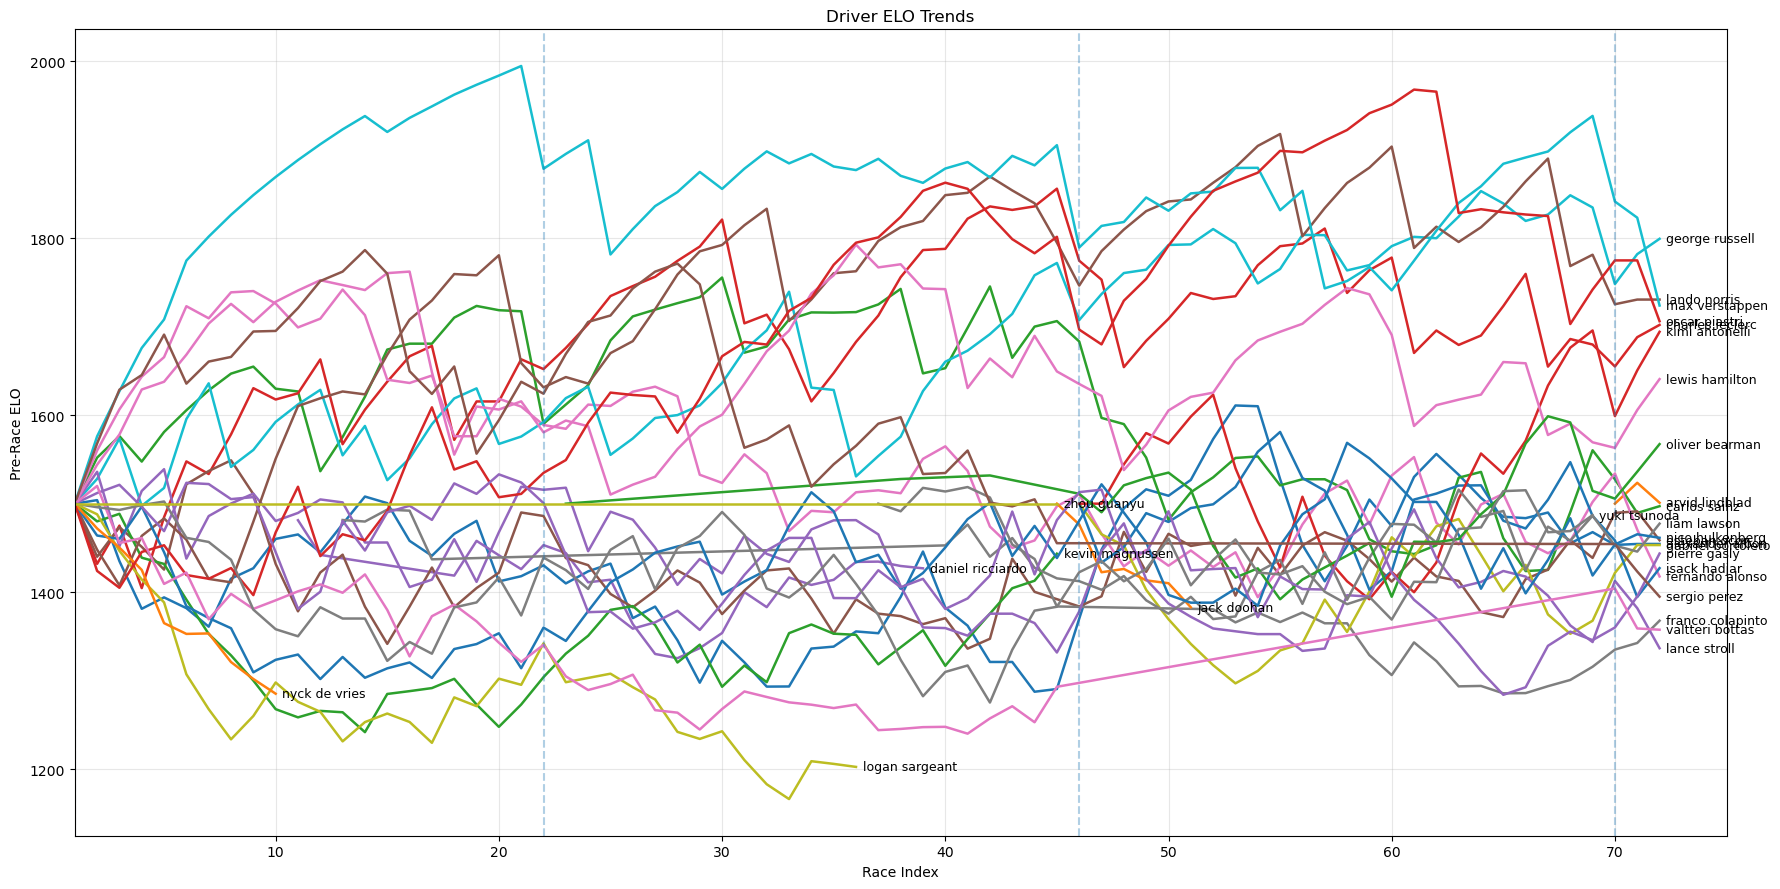

In [ ]:
plt.figure(figsize=(18, 9))

# plot each driver line
for driver in sorted(elo_plot["driver"].unique()):
    sub = elo_plot[elo_plot["driver"] == driver].sort_values("race_index")
    plt.plot(sub["race_index"], sub["elo_before"], linewidth=1.8)

    # label at last point
    last_x = sub["race_index"].iloc[-1]
    last_y = sub["elo_before"].iloc[-1]

    plt.text(
        last_x + 0.3,   # push label slightly right of the line
        last_y,
        driver,
        fontsize=9,
        va="center"
    )

# season boundaries
season_starts = (
    race_order.groupby("year", as_index=False)["race_index"]
    .min()
)

for _, row in season_starts.iterrows():
    plt.axvline(row["race_index"], linestyle="--", alpha=0.35)

plt.xlabel("Race Index")
plt.ylabel("Pre-Race ELO")
plt.title(f"Driver ELO Trends")
plt.grid(True, alpha=0.3)

# extend x-axis so labels fit on the right
plt.xlim(elo_plot["race_index"].min(), elo_plot["race_index"].max() + 3)

plt.tight_layout()
plt.show()

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT DISTINCT
            d.driver_name AS fact_driver_name,
            elo.driver AS elo_driver_name
        FROM fact_driver_race f
        LEFT JOIN dim_driver d
            ON f.driver_id = d.driver_id
        LEFT JOIN staged_elo_table elo
            ON f.race_id = elo.race_id
            AND d.driver_name = elo.driver
        WHERE f.elo_before IS NULL
        ORDER BY d.driver_name
    """).df()
df

,fact_driver_name,elo_driver_name
0,nico hulkenberg,None
1,nyck de vries,None
2,oliver bearman,None
3,oscar piastri,None
4,pierre gasly,None
5,sergio perez,None
6,valtteri bottas,None
7,yuki tsunoda,None
8,zhou guanyu,None


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT DISTINCT
            driver
        FROM staged_elo_table
        WHERE driver LIKE '%hulkenberg%'
           OR driver LIKE '%vries%'
           OR driver LIKE '%bearman%'
           OR driver LIKE '%piastri%'
           OR driver LIKE '%gasly%'
           OR driver LIKE '%perez%'
           OR driver LIKE '%bottas%'
           OR driver LIKE '%tsunoda%'
           OR driver LIKE '%zhou%'
           OR driver LIKE '%guanyu%'
        ORDER BY driver
    """).df()

df

,driver
0,oliver bearman


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT DISTINCT
            driver
        FROM stage_driver_placement
        WHERE driver IN (
            'nico hulkenberg',
            'nyck de vries',
            'oscar piastri',
            'pierre gasly',
            'sergio perez',
            'valtteri bottas',
            'yuki tsunoda',
            'zhou guanyu'
        )
        ORDER BY driver
    """).df()

df

,driver
0,nico hulkenberg
1,nyck de vries
2,oscar piastri
3,pierre gasly
4,sergio perez
5,valtteri bottas
6,yuki tsunoda
7,zhou guanyu


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            driver,
            COUNT(*) AS rows,
            SUM(CASE WHEN finish_position IS NULL THEN 1 ELSE 0 END) AS null_finish_position,
            SUM(CASE WHEN finish_position = 0 THEN 1 ELSE 0 END) AS zero_finish_position
        FROM stage_driver_placement
        GROUP BY driver
        ORDER BY driver
    """).df()

df

,driver,rows,null_finish_position,zero_finish_position
0,alexander albon,95,0.0,0.0
1,arvid lindblad,7,0.0,0.0
2,carlos sainz,94,0.0,0.0
3,charles leclerc,95,0.0,0.0
4,daniel ricciardo,31,0.0,0.0
5,esteban ocon,94,0.0,0.0
6,fernando alonso,95,0.0,0.0
7,franco colapinto,41,0.0,0.0
8,gabriel bortoleto,37,0.0,0.0
9,george russell,95,0.0,0.0


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT DISTINCT
            driver
        FROM staged_elo_table
        WHERE driver IN (
            'nico hulkenberg',
            'nyck de vries',
            'oscar piastri',
            'pierre gasly',
            'sergio perez',
            'valtteri bottas',
            'yuki tsunoda',
            'zhou guanyu'
        )
        ORDER BY driver
    """).df()
df

,driver
0,nico hulkenberg
1,nyck de vries
2,oscar piastri
3,pierre gasly
4,sergio perez
5,valtteri bottas
6,yuki tsunoda
7,zhou guanyu


In [ ]:
def test_staged_elo():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT
                race_id,
                driver,
                COUNT(*)
            FROM staged_elo_table
            GROUP BY race_id, driver
            HAVING COUNT(*) > 1;
        """).df()
    return result


elo_table = test_staged_elo()
elo_table

,race_id,driver,count_star()


In [ ]:
def test_staged_elo():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT
                driver,
                elo_before,
                elo_delta,
                elo_after
            FROM staged_elo_table
            WHERE elo_delta IS NULL
        """).df()
    return result


elo_table = test_staged_elo()
elo_table

,driver,elo_before,elo_delta,elo_after


### Pre Race Driver Features Testing

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    res = con.execute("""

        WITH base AS (
            SELECT
                fdr.year,
                fdr.race_id,
                fdr.date_start,
                fdr.date_end,
                fdr.circuit_short_name,
                fdr.is_sprint_weekend,
                fdr.country_name,
                fdr.driver_id,
                fdr.constructor_id,
                fdr.price,
                fdr.fantasy_points,
                fdr.elo_before
            FROM fact_driver_race AS fdr
        ),

        lagged AS (
            SELECT
                *,
                
                LAG(price) OVER (
                    PARTITION BY driver_id
                    ORDER BY date_start
                ) AS prev_price,

                LAG(fantasy_points) OVER (
                    PARTITION BY driver_id
                    ORDER BY date_start
                ) AS prev_points

            FROM base
        ),

        rolling AS (
            SELECT
                *,

                price - prev_price AS price_change_prev_race,
                (price - prev_price) / NULLIF(prev_price, 0) AS price_change_pct_prev_race,

                AVG(prev_points) OVER (
                    PARTITION BY driver_id
                    ORDER BY date_start
                    ROWS BETWEEN 4 PRECEDING AND CURRENT ROW
                ) AS points_last_5_avg,
                      
                AVG(prev_points) OVER (
                    PARTITION BY driver_id
                    ORDER BY date_start
                    ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
                ) AS points_last_3_avg

            FROM lagged
        ),

        feature_calc AS (
            SELECT
                *,

                points_last_5_avg / NULLIF(price, 0) AS ppm_last_5,

                CASE 
                    WHEN price_change_prev_race > 0 THEN 1 
                    ELSE 0 
                END AS price_increase,

                CASE 
                    WHEN price_change_prev_race < 0 THEN 1 
                    ELSE 0 
                END AS price_decrease

            FROM rolling
        ),

        teammate_features AS (
            SELECT
                *,

                SUM(points_last_5_avg) OVER (
                    PARTITION BY year, race_id, constructor_id
                ) - points_last_5_avg AS teammate_points_last5

            FROM feature_calc
        )

        SELECT
            year,
            race_id,
            date_start,
            date_end,
            circuit_short_name,
            is_sprint_weekend,
            country_name,
            driver_id,
            constructor_id,
            price,
            fantasy_points,
            elo_before,

            price_change_prev_race,
            price_change_pct_prev_race,
            points_last_5_avg,
            ppm_last_5,
            points_last_3_avg - points_last_5_avg AS momentum,

            price_increase,
            price_decrease,

            teammate_points_last5,
            points_last_5_avg - teammate_points_last5 AS teammate_delta_last5

        FROM teammate_features
        ORDER BY race_id;
                      
    """).df()

res.tail()

,year,race_id,date_start,date_end,circuit_short_name,is_sprint_weekend,country_name,driver_id,constructor_id,price,...,elo_before,price_change_prev_race,price_change_pct_prev_race,points_last_5_avg,ppm_last_5,momentum,price_increase,price_decrease,teammate_points_last5,teammate_delta_last5
1462,2026,76,2026-05-01 12:30:00-04:00,2026-05-01 12:30:00-04:00,Miami,False,United States,39,<NA>,7.5,...,1489.084180,0.6,0.086957,12.4,1.653333,4.266667,1,0,256.466667,-244.066667
1463,2026,76,2026-05-01 12:30:00-04:00,2026-05-01 12:30:00-04:00,Miami,False,United States,45,<NA>,5.0,...,1479.236937,-0.6,-0.107143,0.6,0.120000,-1.600000,0,1,268.266667,-267.666667
1464,2026,76,2026-05-01 12:30:00-04:00,2026-05-01 12:30:00-04:00,Miami,False,United States,15,<NA>,9.1,...,1486.837113,0.6,0.070588,13.8,1.516484,0.200000,1,0,255.066667,-241.266667
1465,2026,76,2026-05-01 12:30:00-04:00,2026-05-01 12:30:00-04:00,Miami,False,United States,52,<NA>,24.6,...,1744.804462,-0.3,-0.012048,19.2,0.780488,-11.866667,0,1,249.666667,-230.466667
1466,2026,76,2026-05-01 12:30:00-04:00,2026-05-01 12:30:00-04:00,Miami,False,United States,55,<NA>,13.0,...,1504.694065,0.2,0.015625,10.2,0.784615,4.800000,1,0,258.666667,-248.466667


### running pre_race_driver_features from DB

In [53]:
def prdf_from_db():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM pre_race_driver_features
        """).df()
    return result


prdf = prdf_from_db()

In [54]:
prdf.shape

(1489, 23)

In [ ]:
print(prdf.isna().sum().sort_values(ascending=False).head(20))

year                          0
race_id                       0
date_start                    0
date_end                      0
circuit_short_name            0
is_sprint_weekend             0
country_name                  0
driver_id                     0
constructor_id                0
price                         0
fantasy_points                0
elo_before                    0
price_change_prev_race        0
price_change_pct_prev_race    0
points_last_5_avg             0
ppm_last_5                    0
avg_quali_last_5              0
price_increase                0
price_decrease                0
momentum                      0
dtype: int64


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    result = con.execute("""
                SELECT
                    COUNT(*) AS rows,
                    COUNT(avg_quali_last_5) AS non_null_rows,
                    MIN(avg_quali_last_5) AS min_val,
                    MAX(avg_quali_last_5) AS max_val,
                    AVG(avg_quali_last_5) AS avg_val
                FROM pre_race_driver_features;
                """).df()
result


,rows,non_null_rows,min_val,max_val,avg_val
0,1467,1467,1.0,20.0,10.566371


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    result = con.execute("""
                SELECT
                    year,
                    race_id,
                    driver_id,
                    avg_quali_last_5
                FROM pre_race_driver_features
                WHERE avg_quali_last_5 < 1
                OR avg_quali_last_5 > 25
                ORDER BY avg_quali_last_5 DESC;
                """).df()


result




,year,race_id,driver_id,avg_quali_last_5


In [ ]:

with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    result = con.execute("""
                DESCRIBE pre_race_driver_features
                """).df()


result

,column_name,column_type,null,key,default,extra
0,year,BIGINT,YES,None,None,None
1,race_id,BIGINT,YES,None,None,None
2,date_start,TIMESTAMP WITH TIME ZONE,YES,None,None,None
3,date_end,TIMESTAMP WITH TIME ZONE,YES,None,None,None
4,circuit_short_name,VARCHAR,YES,None,None,None
5,is_sprint_weekend,INTEGER,YES,None,None,None
6,country_name,VARCHAR,YES,None,None,None
7,driver_id,BIGINT,YES,None,None,None
8,constructor_id,BIGINT,YES,None,None,None
9,price,DOUBLE,YES,None,None,None


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
    SELECT COUNT(*)
    FROM pre_race_driver_features
    WHERE isinf(avg_quali_last_5);
    """).df()
df

,count_star()
0,0


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            prdf.year,
            prdf.race_id,
            prdf.driver_id,
            dd.driver_name,
            prdf.constructor_id,
            prdf.price
        FROM pre_race_driver_features as prdf
        JOIN dim_driver as dd
            ON dd.driver_id = prdf.driver_id
        WHERE year = 2026
          AND prdf.race_id = 77
          AND prdf.driver_id IN (44, 45, 65, 66)
        ORDER BY prdf.driver_id
    """).df()

df

,year,race_id,driver_id,driver_name,constructor_id,price


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            year,
            race_id,
            COUNT(*) AS rows,
            MIN(driver_id) AS min_driver_id,
            MAX(driver_id) AS max_driver_id
        FROM pre_race_driver_features
        WHERE year = 2026
        GROUP BY year, race_id
        ORDER BY race_id
    """).df()

df

,year,race_id,rows,min_driver_id,max_driver_id
0,2026,71,22,2,65
1,2026,72,22,2,65
2,2026,73,22,2,65
3,2026,76,22,2,65


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            year,
            race_id,
            COUNT(*) AS rows
        FROM fact_driver_predictions
        WHERE prediction_run_id = 5
        GROUP BY year, race_id
        ORDER BY race_id
    """).df()

df

,year,race_id,rows
0,2026,77,22


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            prdf.year,
            prdf.race_id,
            prdf.driver_id,
            dd.driver_name,
            prdf.constructor_id,
            prdf.price
        FROM pre_race_driver_features AS prdf
        JOIN dim_driver AS dd
            ON dd.driver_id = prdf.driver_id
        WHERE prdf.year = 2026
          AND dd.driver_name IN ('nico hulkenberg', 'valtteri bottas')
        ORDER BY prdf.race_id, dd.driver_name
    """).df()

df

,year,race_id,driver_id,driver_name,constructor_id,price
0,2026,71,44,nico hulkenberg,11,6.8
1,2026,71,65,valtteri bottas,12,5.9
2,2026,72,44,nico hulkenberg,11,6.2
3,2026,72,65,valtteri bottas,12,5.3
4,2026,73,44,nico hulkenberg,11,5.6
5,2026,73,65,valtteri bottas,12,4.7
6,2026,76,44,nico hulkenberg,11,5.0
7,2026,76,65,valtteri bottas,12,4.1


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            p.prediction_run_id,
            p.year,
            p.race_id,
            p.driver_id,
            d.driver_name,
            p.constructor_id,
            p.price,
            p.predicted_points
        FROM fact_driver_predictions AS p
        LEFT JOIN dim_driver AS d
            ON p.driver_id = d.driver_id
        WHERE p.prediction_run_id = 7
          AND p.driver_id IN (44, 45, 65, 66)
        ORDER BY p.driver_id
    """).df()

df

,prediction_run_id,year,race_id,driver_id,driver_name,constructor_id,price,predicted_points
0,7,2026,77,44,nico hulkenberg,11,4.4,4.143521
1,7,2026,77,65,valtteri bottas,12,3.9,1.835594


#### Trying to find bug causing issues for avg_quali_last_5

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    hist_df = con.execute("""
        SELECT * FROM pre_race_driver_features
    """).df()


### Running pre_race_constructor_features from DB

In [52]:
def prcf_from_db():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM pre_race_constructor_features
        """).df()
    return result

prcf = prcf_from_db()
prcf.tail(40)

,year,race_id,date_start,date_end,circuit_short_name,is_sprint_weekend,country_name,constructor_id,price,fantasy_points,price_change_prev_race,price_change_pct_prev_race,points_last_5_avg,points_last_3_avg,ppm_last_5,ppm_last_3,momentum,price_increase,price_decrease
705,2026,72,2026-03-12 23:30:00-04:00,2026-03-12 23:30:00-04:00,Shanghai,1,China,6,13.1,45,0.6,0.048000,11.000000,13.333333,0.839695,1.017812,2.333333,1,0
706,2026,72,2026-03-12 23:30:00-04:00,2026-03-12 23:30:00-04:00,Shanghai,1,China,16,23.6,119,0.3,0.012876,43.800000,58.000000,1.855932,2.457627,14.200000,1,0
707,2026,72,2026-03-12 23:30:00-04:00,2026-03-12 23:30:00-04:00,Shanghai,1,China,33,6.9,50,0.6,0.095238,28.000000,21.000000,4.057971,3.043478,-7.000000,1,0
708,2026,72,2026-03-12 23:30:00-04:00,2026-03-12 23:30:00-04:00,Shanghai,1,China,10,9.7,-20,-0.6,-0.058252,6.200000,10.000000,0.639175,1.030928,3.800000,0,1
709,2026,72,2026-03-12 23:30:00-04:00,2026-03-12 23:30:00-04:00,Shanghai,1,China,11,6.0,-4,-0.6,-0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0,1
710,2026,72,2026-03-12 23:30:00-04:00,2026-03-12 23:30:00-04:00,Shanghai,1,China,12,5.4,22,-0.6,-0.100000,-13.000000,-13.000000,-2.407407,-2.407407,0.000000,0,1
711,2026,72,2026-03-12 23:30:00-04:00,2026-03-12 23:30:00-04:00,Shanghai,1,China,37,28.5,45,0.3,0.010638,66.800000,53.666667,2.343860,1.883041,-13.133333,1,0
712,2026,73,2026-03-26 22:30:00-04:00,2026-03-26 22:30:00-04:00,Suzuka,0,Japan,26,28.5,72,-0.3,-0.010417,30.200000,29.666667,1.059649,1.040936,-0.533333,0,1
713,2026,73,2026-03-26 22:30:00-04:00,2026-03-26 22:30:00-04:00,Suzuka,0,Japan,41,13.2,9,0.6,0.047619,22.800000,22.000000,1.727273,1.666667,-0.800000,1,0
714,2026,73,2026-03-26 22:30:00-04:00,2026-03-26 22:30:00-04:00,Suzuka,0,Japan,30,29.9,92,0.3,0.010135,76.000000,82.000000,2.541806,2.742475,6.000000,1,0


### Current Race Week Rows Testing

In [ ]:
def current_week_testing():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
        WITH target_race AS (
            SELECT *
            FROM dim_race
            WHERE year = 2026
            AND race_num = 7
        ),
        active_driver_prices AS (
            SELECT
                year,
                race,
                driver,
                price
            FROM stage_driver_price_table
            WHERE year = 2026
            AND race = 7
        ),
        latest_history AS (
            SELECT *
            FROM pre_race_driver_features
            QUALIFY ROW_NUMBER() OVER (
                PARTITION BY driver_id
                ORDER BY race_id DESC
            ) = 1
        )
        SELECT
            tr.race_id,
            tr.year,
            tr.race_num,
            tr.race_name,
            d.driver_id,
            d.driver_name,
            c.constructor_id,
            c.constructor_name,
            p.price,

            -- carry/lagged features
            h.points_last_5_avg,
            h.ppm_last_5,
            h.momentum,
            h.teammate_points_last5,
            h.teammate_delta_last5,

            -- upcoming race unknowns
            NULL AS fantasy_points
        FROM target_race tr
        JOIN active_driver_prices p
            ON tr.year = p.year
        AND tr.race_num = p.race
        JOIN dim_driver d
            ON p.driver = d.driver_name
        LEFT JOIN latest_history h
            ON d.driver_id = h.driver_id
        LEFT JOIN dim_constructor c
            ON h.constructor_id = c.constructor_id;
        """).df()
    return result


current_week = current_week_testing()
current_week.head(30)

,race_id,year,race_num,race_name,driver_id,driver_name,constructor_id,constructor_name,price,points_last_5_avg,ppm_last_5,momentum,teammate_points_last5,teammate_delta_last5,fantasy_points
0,77,2026,7,Canadian Grand Prix,43,max verstappen,37,Red Bull Racing,28.3,35.600000,1.262411,-9.933333,3.000000,32.600000,<NA>
1,77,2026,7,Canadian Grand Prix,26,isack hadjar,37,Red Bull Racing,12.7,3.000000,0.225564,2.333333,35.600000,-32.600000,<NA>
2,77,2026,7,Canadian Grand Prix,17,fernando alonso,10,Aston Martin,8.0,2.400000,0.292683,-8.066667,-6.400000,8.800000,<NA>
3,77,2026,7,Canadian Grand Prix,35,lance stroll,10,Aston Martin,5.6,-6.400000,-1.032258,-11.600000,2.400000,-8.800000,<NA>
4,77,2026,7,Canadian Grand Prix,18,franco colapinto,6,Alpine,8.2,6.800000,0.894737,2.533333,10.200000,-3.400000,<NA>
5,77,2026,7,Canadian Grand Prix,55,pierre gasly,6,Alpine,12.8,10.200000,0.784615,4.800000,6.800000,3.400000,<NA>
6,77,2026,7,Canadian Grand Prix,9,carlos sainz,41,Williams,13.0,14.200000,1.145161,-0.533333,3.000000,11.200000,<NA>
7,77,2026,7,Canadian Grand Prix,2,alexander albon,41,Williams,9.6,3.000000,0.294118,-3.000000,14.200000,-11.200000,<NA>
8,77,2026,7,Canadian Grand Prix,39,liam lawson,33,Racing Bulls,8.1,12.400000,1.653333,4.266667,7.666667,4.733333,<NA>
9,77,2026,7,Canadian Grand Prix,6,arvid lindblad,33,Racing Bulls,7.0,7.666667,1.008772,0.000000,12.400000,-4.733333,<NA>


### testing current week constructor features table

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    print(con.execute("""
        SELECT *
        FROM dim_race
        WHERE year = 2026
          AND race_num = 7
    """).df())

    print(con.execute("""
        SELECT *
        FROM stage_constructor_price_table
        WHERE year = 2026
          AND race = 7
    """).df())

   race_id  year  race_num            race_name  meeting_key country_name  \
0       77  2026         7  Canadian Grand Prix         1285       Canada   

  circuit_short_name                date_start                  date_end  \
0           Montreal 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   

   is_sprint_weekend  
0              False  
        constructor  race  price  year
0          mercedes     7   30.5  2026
1           mclaren     7   28.9  2026
2   red bull racing     7   29.2  2026
3           ferrari     7   24.5  2026
4            alpine     7   14.9  2026
5          williams     7   14.4  2026
6      aston martin     7    7.9  2026
7      haas f1 team     7    9.8  2026
8              audi     7    5.0  2026
9      racing bulls     7    8.7  2026
10         cadillac     7    5.6  2026


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    print(con.execute("""
        SELECT year, race, COUNT(*) AS constructor_rows
        FROM stage_constructor_price_table
        WHERE year = 2026
        GROUP BY year, race
        ORDER BY year, race
    """).df())

   year  race  constructor_rows
0  2026     1                11
1  2026     2                11
2  2026     3                11
3  2026     6                11
4  2026     7                11


### Reading Current Week Constructor Features

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    print(con.execute("""
        SELECT *
        FROM dim_constructor
    """).df())

    constructor_id  year constructor_name
0                1  2023       Alfa Romeo
1                2  2023       AlphaTauri
2                3  2023           Alpine
3                4  2024           Alpine
4                5  2025           Alpine
5                6  2026           Alpine
6                7  2023     Aston Martin
7                8  2024     Aston Martin
8                9  2025     Aston Martin
9               10  2026     Aston Martin
10              11  2026             Audi
11              12  2026         Cadillac
12              13  2023          Ferrari
13              14  2024          Ferrari
14              15  2025          Ferrari
15              16  2026          Ferrari
16              17  2023     Haas F1 Team
17              18  2024     Haas F1 Team
18              19  2025     Haas F1 Team
19              20  2026     Haas F1 Team
20              21  2024      Kick Sauber
21              22  2025      Kick Sauber
22              23  2023          

In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    print(con.execute("""
        SELECT *
        FROM current_race_constructor_features
    """).df())

    year  race_id                date_start                  date_end  \
0   2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   
1   2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   
2   2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   
3   2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   
4   2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   
5   2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   
6   2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   
7   2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   
8   2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   
9   2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   
10  2026       77 2026-05-22 12:30:00-04:00 2026-05-22 12:30:00-04:00   

   circuit_short_name  is_sprint_weekend country_name  constructor_id  price  \
0            Montreal                  0   

### Predictions

#### Driver

In [ ]:
def fact_driver_predictions():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM fact_driver_predictions
        """).df()
    return result

fdp = fact_driver_predictions()
fdp


,prediction_run_id,prediction_timestamp,model_name,model_version,feature_set_version,target_variable,train_data_cutoff,is_production_run,year,race_id,driver_id,constructor_id,price,predicted_points
0,1,3/6/2026 23:30,MVP,1,1,points,NaN,True,2026,71,43,39,27.7,38.163860
1,1,3/6/2026 23:30,MVP,1,1,points,NaN,True,2026,71,22,37,27.4,24.508209
2,1,3/6/2026 23:30,MVP,1,1,points,NaN,True,2026,71,36,36,27.2,16.815132
3,1,3/6/2026 23:30,MVP,1,1,points,NaN,True,2026,71,52,36,25.5,16.833676
4,1,3/6/2026 23:30,MVP,1,1,points,NaN,True,2026,71,34,37,23.2,20.579742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,27,2026-05-23 00:26:31.533014,v1,1,4,fantasy_points,76.0,True,2026,77,48,20,9.4,7.060986
348,27,2026-05-23 00:26:31.533014,v1,1,4,fantasy_points,76.0,True,2026,77,51,26,24.7,27.330741
349,27,2026-05-23 00:26:31.533014,v1,1,4,fantasy_points,76.0,True,2026,77,54,6,12.8,6.225418
350,27,2026-05-23 00:26:31.533014,v1,1,4,fantasy_points,76.0,True,2026,77,60,12,7.6,3.587088


In [ ]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    df = con.execute("""
        SELECT
            p.prediction_run_id,
            p.year,
            p.race_id,
            p.driver_id,
            d.driver_name,
            p.constructor_id,
            p.price,
            p.predicted_points
        FROM fact_driver_predictions AS p
        LEFT JOIN dim_driver AS d
            ON p.driver_id = d.driver_id
        WHERE p.prediction_run_id = 5
          AND p.driver_id IN (44, 45, 65, 66)
        ORDER BY p.driver_id
    """).df()

print(df)

   prediction_run_id  year  race_id  driver_id     driver_name  \
0                  5  2026       77         45   nikita bedrin   
1                  5  2026       77         66  victor martins   

   constructor_id  price  predicted_points  
0              11    4.4          4.310226  
1              12    3.9          1.822396  


#### Constructor

In [ ]:
def fact_constructor_predictions():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM fact_constructor_predictions
        """).df()
    return result

fcp = fact_constructor_predictions()
fcp.isna().sum()

prediction_run_id       0
prediction_timestamp    0
model_name              0
model_version           0
feature_set_version     0
target_variable         0
train_data_cutoff       0
is_production_run       0
year                    0
race_id                 0
constructor_id          0
price                   0
predicted_points        0
dtype: int64

In [55]:
def prediction_run():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM prediction_run
        """).df()
    return result

pr = prediction_run()
pr.tail(20)

,prediction_run_id,created_at,model_name,model_version,feature_set_version,target,train_cutoff_race_id,asset_type
9,11,2026-05-15 14:47:25.291475,v1,1,2,fantasy_points,76,driver
10,12,2026-05-15 14:47:32.686196,v1_constructor,1,2,fantasy_points,76,constructor
11,13,2026-05-21 17:08:25.791231,v1,1,3,fantasy_points,76,driver
12,14,2026-05-21 17:08:33.143237,v1_constructor,1,2,fantasy_points,76,constructor
13,15,2026-05-21 18:04:43.163872,v1,1,3,fantasy_points,76,driver
14,16,2026-05-21 18:04:51.054385,v1_constructor,1,2,fantasy_points,76,constructor
15,17,2026-05-22 08:11:10.840281,v1,1,3,fantasy_points,76,driver
16,18,2026-05-22 08:11:18.876413,v1_constructor,1,2,fantasy_points,76,constructor
17,19,2026-05-22 08:32:37.672675,v1,1,3,fantasy_points,76,driver
18,20,2026-05-22 08:32:45.114945,v1_constructor,1,2,fantasy_points,76,constructor


In [ ]:
pr.columns

Index(['prediction_run_id', 'created_at', 'model_name', 'model_version',
       'feature_set_version', 'target', 'train_cutoff_race_id', 'asset_type'],
      dtype='object')

### Model Performance Table

In [ ]:
def model_performance():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM fact_model_results
        """).df()
    return result

mp = model_performance()
mp.groupby("prediction_run_id").size()


prediction_run_id
1      5
2      6
3      5
4     12
5      6
6      6
7      6
8      6
9      6
10     6
11     6
12     6
13     6
14     6
15     6
16     6
17     6
18     6
19     6
20     6
21     2
22     6
23     2
24     6
25     2
26     6
dtype: int64

In [ ]:
mp_13_23_25 = mp[mp["prediction_run_id"].isin([13, 23, 25])]


mp_13_23_25

,prediction_run_id,model_type,cv_mae,cv_mae_std,train_mae,train_rmse,test_mae,test_rmse,expected_improvement,realized_improvement,overfit_underfit,rmse_overfit_underfit_gap,generalization
76,13,LightGBM,10.315653,1.186080,8.965764,12.418144,13.293858,16.902736,0.186389,-0.048507,4.328094,4.484592,2.978205
77,13,RandomForest,10.480171,1.058841,6.350618,8.962763,13.484745,17.261372,0.173413,-0.063562,7.134127,8.298609,3.004574
78,13,ElasticNet,11.088404,1.279324,9.512838,13.010169,13.915817,16.979826,0.125441,-0.097562,4.402980,3.969657,2.827413
79,13,Lasso,11.091999,1.310407,9.513208,13.011198,13.565234,16.840109,0.125157,-0.069911,4.052026,3.828911,2.473236
80,13,Ridge,11.174608,1.328808,9.529080,12.997252,13.994123,16.996335,0.118642,-0.103738,4.465044,3.999083,2.819515
81,13,Linear,11.204808,1.402177,9.531827,12.997139,13.996458,16.997891,0.116260,-0.103922,4.464630,4.000752,2.791650
132,23,LightGBM,10.242024,1.175283,8.898414,12.354815,13.437750,17.209623,0.247013,0.012065,4.539337,4.854808,3.195726
133,23,RandomForest,10.413356,1.065314,6.246381,8.878395,13.698037,17.503081,0.234416,-0.007071,7.451656,8.624686,3.284681
140,25,LightGBM,10.264884,1.184561,8.898413,12.328579,13.431967,17.207951,0.245332,0.012490,4.533554,4.879373,3.167082
141,25,RandomForest,10.414290,1.069960,6.191398,8.806307,13.659591,17.441549,0.234348,-0.004245,7.468193,8.635243,3.245301


In [ ]:
def fnb():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM fact_niave_baselines
        """).df()
    return result

fnb_result = fnb()
fnb_result

,prediction_run_id,test_mae,test_rmse
0,1,12.357000,16.077000
1,2,13.660000,17.540000
2,3,14.680000,18.742000
3,4,12.113813,15.814664
4,5,12.608011,16.448841
5,6,25.817648,31.463640
6,7,13.020727,17.030642
7,8,23.596855,29.623779
8,9,13.020727,17.030642
9,10,23.596855,29.623779


### Mean Baselines Table

In [ ]:
def model_performance():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM fact_niave_baselines
        """).df()
    return result

mp = model_performance()
mp.tail()

,prediction_run_id,test_mae,test_rmse
1,2,13.660000,17.540000
2,3,14.680000,18.742000
3,4,12.113813,15.814664
4,5,12.608011,16.448841
5,6,25.817648,31.463640


### Budget

In [ ]:
def budget():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM fact_budget_table
        """).df()
    return result

budget_table = budget()
budget_table

,year,race,budget
0,2026,1,100.0
1,2026,2,100.9
2,2026,3,103.1
3,2026,6,104.2
4,2026,7,105.1


### Team Config

In [56]:
def team_config():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM fact_team_config
        """).df()
    return result

team_config_table = team_config()
team_config_table

,year,race_id,race,constructor_1_id,constructor_1_name,constructor_2_id,constructor_2_name,driver_1_id,driver_1_name,driver_2_id,driver_2_name,driver_3_id,driver_3_name,driver_4_id,driver_4_name,driver_5_id,driver_5_name,bonus_driver_id,bonus_driver_name,fantasy_team_name
0,2026,73,1,16,Ferrari,33,Racing Bulls,43,max verstappen,10,charles leclerc,44,nico hulkenberg,18,franco colapinto,39,liam lawson,43,max verstappen,Guppies
1,2026,73,1,26,Mclaren,33,Racing Bulls,43,max verstappen,26,isack hadjar,44,nico hulkenberg,18,franco colapinto,39,liam lawson,43,max verstappen,Guppies2
2,2026,74,2,30,Mercedes,33,Racing Bulls,43,max verstappen,48,oliver bearman,44,nico hulkenberg,18,franco colapinto,39,liam lawson,43,max verstappen,Guppies
3,2026,74,2,30,Mercedes,33,Racing Bulls,43,max verstappen,48,oliver bearman,6,arvid lindblad,20,gabriel bortoleto,54,pierre gasly,43,max verstappen,Guppies2
4,2026,75,3,30,Mercedes,33,Racing Bulls,22,george russell,48,oliver bearman,26,isack hadjar,44,nico hulkenberg,39,liam lawson,22,george russell,Guppies
5,2026,75,3,30,Mercedes,33,Racing Bulls,51,oscar piastri,48,oliver bearman,6,arvid lindblad,20,gabriel bortoleto,54,pierre gasly,51,oscar piastri,Guppies2
6,2026,76,6,30,Mercedes,33,Racing Bulls,22,george russell,48,oliver bearman,26,isack hadjar,35,lance stroll,39,liam lawson,22,george russell,Guppies
7,2026,76,6,30,Mercedes,33,Racing Bulls,36,lando norris,48,oliver bearman,6,arvid lindblad,54,pierre gasly,44,nico hulkenberg,36,lando norris,Guppies2


### Optimizer Testing

##### optimizer run

In [ ]:
def optimizer_run():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM optimizer_run
        """).df()
    return result

optimizer_run_table = optimizer_run()
optimizer_run_table

,optimizer_run_id,created_at,year,race_id,fantasy_team_name,driver_prediction_run_id,constructor_prediction_run_id,budget,points_col,free_transfers_avail,...,gross_points,net_points,solver_status,solver_name,is_production_run,profile_source,profile_strategy,optimization_target,require_driver_from_each_constructor,min_drivers_per_selected_constructor
0,1,2026-05-15 12:06:09.797864,2026,77,Guppies,9,10,105.1,predicted_points,2,...,199.68,179.68,1,COIN_CMD,False,None,None,None,<NA>,<NA>
1,2,2026-05-15 12:07:09.888416,2026,77,Guppies,9,10,105.1,predicted_points,2,...,199.68,179.68,1,COIN_CMD,False,None,None,None,<NA>,<NA>
2,3,2026-05-15 12:15:33.925848,2026,77,Guppies,9,10,105.1,predicted_points,3,...,232.56,222.56,1,COIN_CMD,False,None,None,None,<NA>,<NA>
3,4,2026-05-15 12:17:29.394764,2026,77,Guppies,9,10,105.1,predicted_points,3,...,232.56,222.56,1,COIN_CMD,False,None,None,None,<NA>,<NA>
4,5,2026-05-15 12:21:11.929588,2026,77,Guppies,9,10,105.1,predicted_points,3,...,232.56,222.56,1,COIN_CMD,False,None,None,None,<NA>,<NA>
5,6,2026-05-15 12:23:35.124812,2026,77,Guppies,9,10,105.1,predicted_points,3,...,232.56,222.56,1,COIN_CMD,False,None,None,None,<NA>,<NA>
6,7,2026-05-15 12:29:43.084095,2026,77,Guppies,9,10,105.1,predicted_points,3,...,232.56,222.56,1,COIN_CMD,False,None,None,None,<NA>,<NA>
7,8,2026-05-15 12:30:21.538853,2026,77,Guppies,9,10,105.1,predicted_points,3,...,232.56,222.56,1,COIN_CMD,False,None,None,None,<NA>,<NA>
8,9,2026-05-15 12:33:35.052569,2026,77,Guppies,9,10,105.1,predicted_points,3,...,232.56,222.56,1,COIN_CMD,False,None,None,None,<NA>,<NA>
9,10,2026-05-15 12:42:45.196574,2026,77,Guppies,9,10,105.1,predicted_points,3,...,232.56,222.56,1,COIN_CMD,False,None,None,None,<NA>,<NA>


In [ ]:
optimizer_run_table.columns

Index(['optimizer_run_id', 'created_at', 'year', 'race_id',
       'fantasy_team_name', 'driver_prediction_run_id',
       'constructor_prediction_run_id', 'budget', 'points_col',
       'free_transfers_avail', 'total_transfers', 'paid_transfers',
       'transfer_penalty', 'use_drs', 'drs_driver_id', 'total_price',
       'gross_points', 'net_points', 'solver_status', 'solver_name',
       'is_production_run'],
      dtype='object')

##### Optimizer selection

In [ ]:
def optimizer_selection():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT *
            FROM optimizer_selection
        """).df()
    return result

optimizer_selection_table = optimizer_selection()
optimizer_selection_table.tail(12)

,optimizer_run_id,asset_type,driver_id,constructor_id,selected_asset_id,selected_asset_name,price,predicted_points,is_drs,is_transfer_in,slot_num
58,10,driver,35,10,35,lance stroll,5.6,6.101671,False,False,3
59,10,driver,44,11,44,nico hulkenberg,4.4,4.143521,False,True,4
60,10,driver,65,12,65,valtteri bottas,3.9,1.835594,False,True,5
61,10,constructor,<NA>,30,30,Mercedes,30.5,75.918203,False,False,1
62,10,constructor,<NA>,16,16,Ferrari,24.5,69.313360,False,True,2
63,11,driver,22,30,22,george russell,28.6,34.512317,False,False,1
64,11,driver,20,11,20,gabriel bortoleto,5.2,6.844290,False,True,2
65,11,driver,35,10,35,lance stroll,5.6,6.619031,False,False,3
66,11,driver,44,11,44,nico hulkenberg,4.4,4.936139,False,True,4
67,11,driver,65,12,65,valtteri bottas,3.9,3.188463,False,True,5


### Reporting

In [ ]:

with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:

    print("\nDriver prediction races")
    print(con.execute("""
        SELECT year, race_id, COUNT(*) AS rows
        FROM fact_driver_predictions
        GROUP BY year, race_id
        ORDER BY year, race_id
    """).df())

    print("\nDriver actual races")
    print(con.execute("""
        SELECT year, race_id, COUNT(*) AS rows
        FROM fact_driver_race
        GROUP BY year, race_id
        ORDER BY year, race_id
    """).df())

    print("\nConstructor prediction races")
    print(con.execute("""
        SELECT year, race_id, COUNT(*) AS rows
        FROM fact_constructor_predictions
        GROUP BY year, race_id
        ORDER BY year, race_id
    """).df())

    print("\nConstructor actual races")
    print(con.execute("""
        SELECT year, race_id, COUNT(*) AS rows
        FROM fact_constructor_race
        GROUP BY year, race_id
        ORDER BY year, race_id
    """).df())


Driver prediction races
   year  race_id  rows
0  2026       71    22
1  2026       72    22
2  2026       73    22
3  2026       76    22
4  2026       77    88

Driver actual races
    year  race_id  rows
0   2023        1    20
1   2023        2    20
2   2023        3    20
3   2023        4    20
4   2023        5    20
..   ...      ...   ...
68  2025       70    20
69  2026       71    22
70  2026       72    22
71  2026       73    22
72  2026       76    22

[73 rows x 3 columns]

Constructor prediction races
   year  race_id  rows
0  2026       77    33

Constructor actual races
    year  race_id  rows
0   2023        1    10
1   2023        2    10
2   2023        3    10
3   2023        4    10
4   2023        5    10
..   ...      ...   ...
68  2025       70    10
69  2026       71    11
70  2026       72    11
71  2026       73    11
72  2026       76    11

[73 rows x 3 columns]


#### rpt_driver_predictions testing

In [ ]:
with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    result = con.execute("""
                SELECT
                    p.prediction_run_id,
                    p.year,
                    p.race_id,
                    r.race_num,
                    r.race_name,
                    r.country_name,
                    r.circuit_short_name,
                    r.is_sprint_weekend,

                    p.driver_id,
                    d.driver_name,
                    d.name_acronym as driver_acronym,
                    p.constructor_id,
                    c.constructor_name,

                    p.predicted_points,
                    p.model_name,
                    p.model_version,
                    p.feature_set_version,
                    p.target_variable,
                    p.is_production_run,
                    p.prediction_timestamp

                FROM fact_driver_predictions p
                LEFT JOIN dim_driver d
                    ON p.driver_id = d.driver_id
                LEFT JOIN dim_constructor c
                    ON p.constructor_id = c.constructor_id
                LEFT JOIN dim_race r
                    ON p.race_id = r.race_id
                ORDER BY p.prediction_run_id, p.predicted_points DESC
                """).df()
    
result

,prediction_run_id,year,race_id,race_num,race_name,country_name,circuit_short_name,is_sprint_weekend,driver_id,driver_name,driver_acronym,constructor_id,constructor_name,predicted_points,model_name,model_version,feature_set_version,target_variable,is_production_run,prediction_timestamp
0,1,2026,71,1,Australian Grand Prix,Australia,Melbourne,False,43,max verstappen,VER,39,Williams,38.163860,MVP,1,1,points,True,3/6/2026 23:30
1,1,2026,71,1,Australian Grand Prix,Australia,Melbourne,False,22,george russell,RUS,37,Red Bull Racing,24.508209,MVP,1,1,points,True,3/6/2026 23:30
2,1,2026,71,1,Australian Grand Prix,Australia,Melbourne,False,10,charles leclerc,LEC,34,Red Bull Racing,21.135585,MVP,1,1,points,True,3/6/2026 23:30
3,1,2026,71,1,Australian Grand Prix,Australia,Melbourne,False,34,kimi antonelli,ANT,37,Red Bull Racing,20.579742,MVP,1,1,points,True,3/6/2026 23:30
4,1,2026,71,1,Australian Grand Prix,Australia,Melbourne,False,38,lewis hamilton,HAM,34,Red Bull Racing,18.805221,MVP,1,1,points,True,3/6/2026 23:30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,27,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,18,franco colapinto,COL,6,Alpine,4.596360,v1,1,4,fantasy_points,True,2026-05-23 00:26:31.533014
348,27,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,44,nico hulkenberg,HUL,11,Audi,3.835054,v1,1,4,fantasy_points,True,2026-05-23 00:26:31.533014
349,27,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,60,sergio perez,PER,12,Cadillac,3.587088,v1,1,4,fantasy_points,True,2026-05-23 00:26:31.533014
350,27,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,26,isack hadjar,HAD,37,Red Bull Racing,3.476986,v1,1,4,fantasy_points,True,2026-05-23 00:26:31.533014


#### rpt_constructor_predictions

In [ ]:
with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    result = con.execute("""
                SELECT
                    p.prediction_run_id,
                    p.year,
                    p.race_id,
                    r.race_num,
                    r.race_name,
                    r.country_name,
                    r.circuit_short_name,
                    r.is_sprint_weekend,

                    p.constructor_id,
                    c.constructor_name,

                    p.predicted_points,
                    p.model_name,
                    p.model_version,
                    p.feature_set_version,
                    p.target_variable,
                    p.is_production_run,
                    p.prediction_timestamp

                FROM fact_constructor_predictions p
                LEFT JOIN dim_constructor c
                    ON p.constructor_id = c.constructor_id
                LEFT JOIN dim_race r
                    ON p.race_id = r.race_id
                ORDER BY p.prediction_run_id, p.predicted_points DESC
                """).df()
    
result

,prediction_run_id,year,race_id,race_num,race_name,country_name,circuit_short_name,is_sprint_weekend,constructor_id,constructor_name,predicted_points,model_name,model_version,feature_set_version,target_variable,is_production_run,prediction_timestamp
0,8,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,30,Mercedes,75.918203,v1_constructor,1,1,fantasy_points,False,2026-05-15 10:35:05.443900
1,8,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,16,Ferrari,69.313360,v1_constructor,1,1,fantasy_points,False,2026-05-15 10:35:05.443900
2,8,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,26,McLaren,59.993396,v1_constructor,1,1,fantasy_points,False,2026-05-15 10:35:05.443900
3,8,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,37,Red Bull Racing,44.497231,v1_constructor,1,1,fantasy_points,False,2026-05-15 10:35:05.443900
4,8,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,6,Alpine,21.041603,v1_constructor,1,1,fantasy_points,False,2026-05-15 10:35:05.443900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,28,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,10,Aston Martin,21.764836,v1_constructor,1,2,fantasy_points,True,2026-05-23 00:26:38.609760
117,28,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,33,Racing Bulls,19.519816,v1_constructor,1,2,fantasy_points,True,2026-05-23 00:26:38.609760
118,28,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,20,Haas F1 Team,16.380550,v1_constructor,1,2,fantasy_points,True,2026-05-23 00:26:38.609760
119,28,2026,77,7,Canadian Grand Prix,Canada,Montreal,True,12,Cadillac,11.550581,v1_constructor,1,2,fantasy_points,True,2026-05-23 00:26:38.609760


### Qualifying Testing

In [ ]:
with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    result = con.execute("""
            SELECT
                race_id,
                driver_id,
                driver_name,
                COUNT(*) AS rows,
                LIST(session_key) AS session_keys,
                LIST(qualifying_position) AS positions
            FROM staged_qualifying_results_table
            GROUP BY race_id, driver_id, driver_name
            HAVING COUNT(*) > 1
            ORDER BY rows DESC, race_id, driver_name;              
                         """).df()
    
result

,race_id,driver_id,driver_name,rows,session_keys,positions


In [ ]:
with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    result = con.execute("""
            SELECT
                q.year,
                q.race_id,
                q.driver_name,
                q.session_key,
                s.session_type,
                s.session_name,
                q.qualifying_position
            FROM staged_qualifying_results_table q
            LEFT JOIN staged_race_sessions_table s
                ON q.session_key = s.session_key
            WHERE (q.race_id, q.driver_id) IN (
                SELECT race_id, driver_id
                FROM staged_qualifying_results_table
                GROUP BY race_id, driver_id
                HAVING COUNT(*) > 1
            )
            ORDER BY q.race_id, q.driver_name, q.session_key;           
                         """).df()
    
result

,year,race_id,driver_name,session_key,session_type,session_name,qualifying_position


In [ ]:
with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    result = con.execute("""
        SELECT
            fdr.year,
            fdr.race_id,
            COUNT(*) AS fdr_rows,
            COUNT(fdr.qualifying_position) AS rows_with_quali
        FROM fact_driver_race fdr
        GROUP BY fdr.year, fdr.race_id
        HAVING COUNT(fdr.qualifying_position) = 0
        ORDER BY fdr.year, fdr.race_id;       
                         """).df()
    
result

,year,race_id,fdr_rows,rows_with_quali
0,2023,12,20,0


In [ ]:
with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    result = con.execute("""
        SELECT
            session_key,
            session_type,
            session_name,
            date_start,
            meeting_key
        FROM staged_race_sessions_table
        WHERE meeting_key = (
            SELECT meeting_key
            FROM dim_race
            WHERE race_id = 12
        )
        ORDER BY date_start;    
                         """).df()
    
result

,session_key,session_type,session_name,date_start,meeting_key
0,9134,Practice,Practice 1,2023-07-28 07:30:00-04:00,1216
1,9135,Qualifying,Qualifying,2023-07-28 11:00:00-04:00,1216
2,9286,Qualifying,Sprint Qualifying,2023-07-29 06:00:00-04:00,1216
3,9140,Race,Sprint,2023-07-29 11:05:00-04:00,1216
4,9141,Race,Race,2023-07-30 09:00:00-04:00,1216


In [ ]:
with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    result = con.execute("""
        SELECT *
        FROM raw_quali_results_table
        WHERE session_key = 9689; 
                         """).df()
    
result

,position,driver_number,number_of_laps,dnf,dns,dsq,duration,gap_to_leader,meeting_key,session_key
0,1.0,4,20,False,False,False,"[75.912, 75.415, 75.096]","[0.0, 0.0, 0.0]",1254,9689
1,2.0,81,18,False,False,False,"[76.062, 75.468, 75.18]","[0.15, 0.053, 0.084]",1254,9689
2,3.0,1,17,False,False,False,"[76.018, 75.565, 75.481]","[0.106, 0.15, 0.385]",1254,9689
3,4.0,63,21,False,False,False,"[75.971, 75.798, 75.546]","[0.059, 0.383, 0.45]",1254,9689
4,5.0,22,18,False,False,False,"[76.225, 76.009, 75.67]","[0.313, 0.594, 0.574]",1254,9689
5,6.0,23,21,False,False,False,"[76.245, 76.017, 75.737]","[0.333, 0.602, 0.641]",1254,9689
6,7.0,16,20,False,False,False,"[76.029, 75.827, 75.755]","[0.117, 0.412, 0.659]",1254,9689
7,8.0,44,23,False,False,False,"[76.213, 75.919, 75.973]","[0.301, 0.504, 0.877]",1254,9689
8,9.0,10,21,False,False,False,"[76.328, 76.112, 75.98]","[0.416, 0.697, 0.884]",1254,9689
9,10.0,55,21,False,False,False,"[76.36, 75.931, 76.062]","[0.448, 0.516, 0.966]",1254,9689


In [ ]:
import requests
import pandas as pd

url = "https://api.openf1.org/v1/session_result"
params = {"session_key": 9135}

response = requests.get(url, params=params, timeout=30)

print("URL:", response.url)
print("Status code:", response.status_code)
print("Response text:", response.text[:500])

if response.ok:
    df = pd.DataFrame(response.json())
    print(df.shape)
    print(df.head())

URL: https://api.openf1.org/v1/session_result?session_key=9135
Status code: 404
Response text: {"detail":"No results found."}


### Trying to understand Pricing Algo for a pricing model

this pulls pricing data to try and understand price change patterns or behavior. Will export to excel to do some faster analysis

In [ ]:
with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    result = con.execute("""

        WITH driver_price_history AS (
            SELECT
                fdr.year,
                fdr.race_id,
                dr.race_num,
                dr.race_name,

                fdr.driver_id,
                fdr.constructor_id,

                fdr.price,
                fdr.fantasy_points,

                LAG(fdr.price) OVER (
                    PARTITION BY fdr.driver_id
                    ORDER BY fdr.year, dr.race_num
                ) AS prev_price,

                LEAD(fdr.price) OVER (
                    PARTITION BY fdr.driver_id
                    ORDER BY fdr.year, dr.race_num
                ) AS next_price,

                COUNT(fdr.fantasy_points) OVER (
                    PARTITION BY fdr.driver_id
                    ORDER BY fdr.year, dr.race_num
                    ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
                ) AS lagged_3_race_count,

                AVG(fdr.fantasy_points) OVER (
                    PARTITION BY fdr.driver_id
                    ORDER BY fdr.year, dr.race_num
                    ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
                ) AS lagged_3_race_points_avg

            FROM fact_driver_race fdr

            JOIN dim_race dr
                ON fdr.race_id = dr.race_id

            JOIN dim_driver dd
                ON fdr.driver_id = dd.driver_id

            JOIN dim_constructor dc
                ON fdr.constructor_id = dc.constructor_id
        )

        SELECT
            year,
            race_id,
            race_num,
            race_name,

            driver_id,
            constructor_id,

            ROUND(price, 2) AS current_price,
            ROUND(prev_price, 2) AS prev_price,
            ROUND(next_price, 2) AS next_price,

            ROUND(next_price - price, 2) AS next_price_delta,

            ROUND(fantasy_points, 2) AS fantasy_points,

            lagged_3_race_count,
            ROUND(lagged_3_race_points_avg, 2) AS lagged_3_race_points_avg,

            CASE
                WHEN price < 18.5 THEN 'below_18_5'
                ELSE 'above_18_5'
            END AS price_tier,

            ROUND(34.0 - price, 2) AS distance_from_ceiling,
            ROUND(price - 3.0, 2) AS distance_from_floor,

            CASE
                WHEN price >= 34.0 THEN 1 ELSE 0
            END AS at_price_ceiling,

            CASE
                WHEN price <= 3.0 THEN 1 ELSE 0
            END AS at_price_floor

        FROM driver_price_history
        WHERE next_price IS NOT NULL
        AND lagged_3_race_count = 3
        ORDER BY year, race_num, price;
""").df()
    
result

,year,race_id,race_num,race_name,driver_id,constructor_id,current_price,prev_price,next_price,next_price_delta,fantasy_points,lagged_3_race_count,lagged_3_race_points_avg,price_tier,distance_from_ceiling,distance_from_floor,at_price_ceiling,at_price_floor
0,2023,4,4,Azerbaijan Grand Prix,40,38,3.8,3.9,3.7,-0.1,0.0,3,6.00,below_18_5,30.2,0.8,0,0
1,2023,4,4,Azerbaijan Grand Prix,44,17,4.1,4.1,4.0,-0.1,2.0,3,3.67,below_18_5,29.9,1.1,0,0
2,2023,4,4,Azerbaijan Grand Prix,68,2,4.8,4.8,4.7,-0.1,-13.0,3,8.00,below_18_5,29.2,1.8,0,0
3,2023,4,4,Azerbaijan Grand Prix,47,2,4.9,5.0,4.8,-0.1,-15.0,3,6.00,below_18_5,29.1,1.9,0,0
4,2023,4,4,Azerbaijan Grand Prix,70,1,4.9,4.9,4.8,-0.1,-10.0,3,12.00,below_18_5,29.1,1.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1346,2026,73,3,Japanese Grand Prix,34,30,23.8,23.5,24.1,0.3,50.0,3,35.00,above_18_5,10.2,20.8,0,0
1347,2026,73,3,Japanese Grand Prix,51,26,24.9,25.2,24.6,-0.3,43.0,3,2.33,above_18_5,9.1,21.9,0,0
1348,2026,73,3,Japanese Grand Prix,36,26,26.8,27.1,26.5,-0.3,24.0,3,13.33,above_18_5,7.2,23.8,0,0
1349,2026,73,3,Japanese Grand Prix,22,30,28.0,27.7,28.3,0.3,27.0,3,34.67,above_18_5,6.0,25.0,0,0


In [ ]:
result.to_csv("pricing_data_for_analysis_5_23.csv")

### Simulation Logging Testing

In [58]:
def simulation_run():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT
                *
            FROM simulation_run
            ORDER BY simulation_run_id DESC
        """).df()
    return result

simulation_run_table = simulation_run()
simulation_run_table

,simulation_run_id,created_at,race_id,driver_prediction_run_id,constructor_prediction_run_id,n_sims,random_seed,residual_source_table,residual_bucket_strategy,notes
0,4,2026-06-01 15:49:14.374092,78,29,30,10000,42,driver_prediction_residuals,00_20_vs_20_plus,test MVP simulation run
1,3,2026-06-01 15:33:09.185736,77,25,26,10000,42,driver_prediction_residuals,00_20_vs_20_plus,test MVP simulation run
2,2,2026-05-29 10:53:34.823334,77,25,26,10000,42,driver_prediction_residuals,00_20_vs_20_plus,test MVP simulation run
3,1,2026-05-29 10:51:53.896464,77,25,26,10000,42,driver_prediction_residuals,00_20_vs_20_plus,test MVP simulation run


In [62]:
def simulation_driver_summary():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT
                *
            FROM simulation_driver_summary
            WHERE simulation_run_id = (
                SELECT MAX(simulation_run_id)
                FROM simulation_run
            )
            ORDER BY mean_sim_points DESC;
        """).df()
    return result

simulation_driver_summary_table = simulation_driver_summary()
simulation_driver_summary_table

,simulation_run_id,race_id,driver_id,constructor_id,price,predicted_points,prediction_bucket,mean_sim_points,std_sim_points,p05,p10,p25,median,p75,p90,p95,mean_per_price,p90_per_price,risk_range,downside_gap
0,4,78,34,30,24.7,31.730249,20_plus,38.113202,17.140392,4.714536,10.434880,27.957471,41.835735,46.222040,58.388541,60.658705,1.543045,2.363909,47.953661,27.678322
1,4,78,43,37,28.4,31.643755,20_plus,37.586025,17.338220,-3.313684,10.348386,27.870977,41.749241,46.135546,58.302047,60.572211,1.323452,2.052889,47.953661,27.237638
2,4,78,22,30,28.5,29.526069,20_plus,35.352533,17.273247,2.510356,8.230701,25.753291,39.631555,44.017860,56.184362,58.454525,1.240440,1.971381,47.953661,27.121833
3,4,78,10,16,24.1,28.130317,20_plus,34.256677,17.159003,1.114604,6.834949,24.357539,38.235803,42.622108,54.788610,57.058773,1.421439,2.273386,47.953661,27.421728
4,4,78,38,16,23.6,24.424638,20_plus,30.642694,17.199645,-2.591075,3.129270,20.651860,34.530124,38.916429,51.082931,53.353094,1.298419,2.164531,47.953661,27.513425
5,4,78,36,26,26.5,20.400122,20_plus,26.105940,17.286625,-6.615591,-0.895247,16.627344,30.505608,34.891913,47.058414,49.328578,0.985130,1.775789,47.953661,27.001187
6,4,78,51,26,25.0,19.244338,00_20,20.479000,15.865939,-4.675234,-1.766780,10.358925,21.718560,27.858355,34.915777,44.866995,0.819160,1.396631,36.682557,22.245780
7,4,78,9,41,12.8,5.052596,00_20,6.557409,16.066540,-18.866975,-15.958522,-3.832817,7.526819,15.743593,20.724035,30.675253,0.512298,1.619065,36.682557,22.515931
8,4,78,48,20,8.8,4.876506,00_20,6.115915,15.823021,-19.043065,-16.134612,-4.008907,7.350729,13.490523,20.547945,30.499163,0.694990,2.334994,36.682557,22.250526
9,4,78,54,6,12.2,3.950680,00_20,5.425524,15.953585,-19.968892,-17.060438,-4.934733,6.424902,14.641677,19.622119,29.573337,0.444715,1.608370,36.682557,22.485962


In [63]:
def simulation_profile_result():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT
                *
            FROM simulation_profile_result
            WHERE simulation_run_id = (
                SELECT MAX(simulation_run_id)
                FROM simulation_run
            )
            ORDER BY mean_lineup_points DESC;
        """).df()
    return result

simulation_profile_results_table = simulation_profile_result()
simulation_profile_results_table

,simulation_run_id,profile_name,profile_source,profile_strategy,optimizer_run_id,mean_lineup_points,std_lineup_points,p05,p10,p25,median,p75,p90,p95
0,4,constructor_required,optimizer,constructor_required,24,83.803195,36.987075,22.465527,36.278123,59.360786,83.965937,108.409243,130.186091,144.213185
1,4,double_stack_constructors,optimizer,double_stack_constructors,25,83.803195,36.987075,22.465527,36.278123,59.360786,83.965937,108.409243,130.186091,144.213185
2,4,max_projected_points,optimizer,max_projected_points,23,54.566576,36.486895,-3.992614,8.381039,30.213367,54.157287,77.785904,100.985493,116.311895
3,4,prior_week_team,benchmark,prior_week_team,<NA>,45.689993,32.673738,-7.560117,4.003143,23.700522,45.487656,67.019676,86.473204,100.016887


#### comparing assets from two different profiles for testing purposes

In [64]:
def simulation_profile_result():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT
                spr.simulation_run_id,
                spr.profile_name,
                spr.profile_strategy,
                spr.optimizer_run_id,

                os.asset_type,
                os.slot_num,
                os.selected_asset_name,
                os.driver_id,
                os.constructor_id,
                os.price,
                os.predicted_points

            FROM simulation_profile_result spr
            LEFT JOIN optimizer_selection os
                ON spr.optimizer_run_id = os.optimizer_run_id

            WHERE spr.simulation_run_id = 4
            AND spr.profile_strategy IN (
                'constructor_required',
                'double_stack_constructor',
                'double_stack_constructors'
            )

            ORDER BY
                spr.profile_strategy,
                os.asset_type,
                os.slot_num;
        """).df()
    return result

simulation_profile_results_table = simulation_profile_result()
simulation_profile_results_table

,simulation_run_id,profile_name,profile_strategy,optimizer_run_id,asset_type,slot_num,selected_asset_name,driver_id,constructor_id,price,predicted_points
0,4,constructor_required,constructor_required,24,constructor,1,Mercedes,<NA>,30,30.8,68.385441
1,4,constructor_required,constructor_required,24,constructor,2,Audi,<NA>,11,4.4,7.274541
2,4,constructor_required,constructor_required,24,driver,1,kimi antonelli,34,30,24.7,31.730249
3,4,constructor_required,constructor_required,24,driver,2,george russell,22,30,28.5,29.526069
4,4,constructor_required,constructor_required,24,driver,3,gabriel bortoleto,20,11,5.4,2.741267
5,4,constructor_required,constructor_required,24,driver,4,lance stroll,35,10,5.4,1.925540
6,4,constructor_required,constructor_required,24,driver,5,nico hulkenberg,44,11,3.8,1.901265
7,4,double_stack_constructors,double_stack_constructors,25,constructor,1,Mercedes,<NA>,30,30.8,68.385441
8,4,double_stack_constructors,double_stack_constructors,25,constructor,2,Audi,<NA>,11,4.4,7.274541
9,4,double_stack_constructors,double_stack_constructors,25,driver,1,kimi antonelli,34,30,24.7,31.730249
